In [495]:
import math
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import unicodedata
import geopandas as gpd
from typing import Dict
from IPython.display import display

# 0. Import Datasets:

In [496]:
customers_db = pd.read_csv("../data/DM_AIAI_CustomerDB.csv", sep=",", index_col=0)
flights_db = pd.read_csv("../data/DM_AIAI_FlightsDB.csv", sep=",")

In [497]:
customers_db.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [498]:
customers_db.shape

(16921, 20)

In [499]:
flights_db.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [500]:
flights_db.shape

(608436, 10)

- **Customers database has 16921 rows and 20 columns**
- **flights database has 608436 rows and 9 columns**

# 1. Analysis of each table separately:

## 1.1. CustomersDB:

### 1.1.3. Descriptives:

In [501]:
cols_customers = customers_db.columns.values
print(cols_customers)

['Loyalty#' 'First Name' 'Last Name' 'Customer Name' 'Country'
 'Province or State' 'City' 'Latitude' 'Longitude' 'Postal code' 'Gender'
 'Education' 'Location Code' 'Income' 'Marital Status' 'LoyaltyStatus'
 'EnrollmentDateOpening' 'CancellationDate' 'Customer Lifetime Value'
 'EnrollmentType']


In [502]:
customers_db.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,259251.503597,100011.0,326823.0,550896.0,772438.0,999999.0
First Name,16921,4941,Stacey,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Ypina,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Cecilia Householder,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578
Postal code,16921,75,V6E 3D9,917,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Population size = 16921 customers**

---

**Loyalty#:**
- 16,921 rows and 16,757 unique: 164 repeated IDs.
- Implication: 1-customer-1-row rule is violated for repeated IDs.

**Customer_Name:**
- Cardinality: 16,921 unique (top has freq 1).
- Implication: appears unique per row. (customerID)

**Country:**
- Only 1 unique value: Canada.
- Implication: Field is not representative.

**Province or State:**
- Unique: 11; top: Ontario (5,468).

**City:**
- Unique: 29; top: Toronto (3,390).

**Latitude / Longitude:**
- Lat mean (≈47.17), IQR ~44.23–49.28, 
- Lon mean (≈−91.81), IQR ~−120.24–−74.60; 
- Implication: values look plausible. Ranges stay within Canada bounds.

**Postal code:**
- Unique: 75 for 16,921 customers; top: V6E 3D9 (917).
- Implication: strong reuse of a small set of postcodes (likely area/office codes, not individualized addresses).

**Gender:**
- Unique: 2; top: female (8,497).
- Implication: near-balanced.

**Education:**
- Unique: 5; top: Bachelor (10,586).
- Implication: Higher-education skew.

**Location Code:**
- Unique: 3; top: Suburban (5,716).

**Income:**
- Count: 16,901 (20 missing); Q1=0; max ≈ 99,981; sd = 30368,992499
- Implication: zeros present (true zeros or placeholders) and wide spread.

**Marital Status:**
- Unique: 3; top: Married (9,842).
- Implication: Most customers are married. 

**LoyaltyStatus:**
- Unique: 3; top: Star (7,761).
- Implication: Tier membership is skewed toward Star, suggesting many customers sit in the top tier.

**EnrollmentDateOpening:**
- Count: 16,921 (no missing).
- Timeline: min 2015-01-27, median ~2018-10-31, 75% ≥ 2020-07-09, max 2021-12-30.
- Implication: The customer base spans cohorts from 2015 to 2021, with a sizable recent wave after mid-2020. Tenure varies widely.

**CancellationDate:**
- Count shown: 914 present (majority missing: active customers).
- Timeline (present values): 2015-12-09 to 2021-12-12 (IQR around 2019–2021).
- Missing values: active customers.  
- Implication: Only a small slice of customers show a cancellation date, and those dates cluster between 2019 and 2021. The dataset is dominated by active customers.

**Customer Lifetime Value:**
- Count: 16,901 (20 missing); median ≈ 5780.18; Q3= 8945.69; max= 83325.38
- Implication: CLV is strongly right-skewed, indicating a small subset of very high-value customers. 

**EnrollmentType:**
- Unique: 2; top: Standard (15,773).
- Implication: Most customers signed up via the standard enrollment type, and only a small slice via 2021 promotion. (class imbalance).
- Confounding problem: The label '2021 promotion' implies those customers likely joined 2021. If we just compare standard vs promotion, we might attribute those differences to the channel, when they're actually due to when people enrolled. 
 

In [503]:
customers_db.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16921 entries, 0 to 19
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loyalty#                 16921 non-null  int64  
 1   First Name               16921 non-null  object 
 2   Last Name                16921 non-null  object 
 3   Customer Name            16921 non-null  object 
 4   Country                  16921 non-null  object 
 5   Province or State        16921 non-null  object 
 6   City                     16921 non-null  object 
 7   Latitude                 16921 non-null  float64
 8   Longitude                16921 non-null  float64
 9   Postal code              16921 non-null  object 
 10  Gender                   16921 non-null  object 
 11  Education                16921 non-null  object 
 12  Location Code            16921 non-null  object 
 13  Income                   16901 non-null  float64
 14  Marital Status           16921

**Wrong Datatypes:**
- **Loyalty#** - From int64 to string
- **EnrollmentDateOpening** - From object to date
- **CancellationDate** - From object to date

### 1.1.1. Datatypes:

In [504]:
# Convert loyalty# to string:
customers_db["Loyalty#"] = customers_db["Loyalty#"].astype("string")

# Convert EnrollmentDateOpening and CancellationDate to datetime:
customers_db[['EnrollmentDateOpening','CancellationDate']] = customers_db[['EnrollmentDateOpening','CancellationDate']].apply(lambda s: pd.to_datetime(s, errors='coerce'))

In [505]:
customers_db.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16921 entries, 0 to 19
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Loyalty#                 16921 non-null  string        
 1   First Name               16921 non-null  object        
 2   Last Name                16921 non-null  object        
 3   Customer Name            16921 non-null  object        
 4   Country                  16921 non-null  object        
 5   Province or State        16921 non-null  object        
 6   City                     16921 non-null  object        
 7   Latitude                 16921 non-null  float64       
 8   Longitude                16921 non-null  float64       
 9   Postal code              16921 non-null  object        
 10  Gender                   16921 non-null  object        
 11  Education                16921 non-null  object        
 12  Location Code            16921 non-null 

### 1.1.2. Duplicates:

In [506]:
nr_full_duplicates_customers = customers_db.duplicated(keep=False).sum()
total_rows = len(customers_db)
pct_full_duplicates = (nr_full_duplicates_customers / total_rows) * 100

print(f"Total number of full duplicates: {nr_full_duplicates_customers} "
      f"({pct_full_duplicates:.2f}%)")

Total number of full duplicates: 0 (0.00%)


**There are no full duplicate records.**

### 1.1.3. Missing Values:

In [507]:
total_missing = customers_db.isna().sum().sum()
total_missing_pct = (total_missing / flights_db.size) * 100  

print(f"Total missing values: {total_missing:,} ({total_missing_pct:.2f}%) ")

missing_by_col = (
    customers_db.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: d["missing_count"] / len(customers_db) * 100)
    .sort_values("missing_pct", ascending=False)
)

print("\nMissing values by column (count and % of rows):")
print(missing_by_col)

Total missing values: 14,653 (0.24%) 

Missing values by column (count and % of rows):
                         missing_count  missing_pct
CancellationDate                 14613    86.360144
Income                              20     0.118196
Customer Lifetime Value             20     0.118196
Loyalty#                             0     0.000000
Customer Name                        0     0.000000
Last Name                            0     0.000000
First Name                           0     0.000000
Country                              0     0.000000
Longitude                            0     0.000000
Province or State                    0     0.000000
City                                 0     0.000000
Latitude                             0     0.000000
Education                            0     0.000000
Gender                               0     0.000000
Postal code                          0     0.000000
Location Code                        0     0.000000
LoyaltyStatus                

Let's check if missing values for Income and Customer Lifetime Value are for the same customers:

In [508]:
m_income = customers_db["Income"].isna()
m_clv = customers_db["Customer Lifetime Value"].isna()

both_missing_mask = m_income & m_clv
both_missing = customers_db.loc[both_missing_mask]

n = len(customers_db)  
print(f"Rows with both Income and Customer Lifetime Value missing: {both_missing.shape[0]}")
print(f"% both Income and Customer Lifetime Value missing: {both_missing.shape[0] / n * 100:.2f}%")

Rows with both Income and Customer Lifetime Value missing: 20
% both Income and Customer Lifetime Value missing: 0.12%


**We can conclude that missing values for CLV and Income are common to the same customers.**

### 1.1.4. Unique Values:

In [509]:
for column in customers_db.columns:
    unique_values = customers_db[column].unique()
    unique_values_num = customers_db[column].nunique()
    print(f"Unique values in '{column}':")
    print(unique_values)
    print(f"Number of unique values in '{column}':")
    print(unique_values_num)
    
    print()

Unique values in 'Loyalty#':
<StringArray>
['480934', '549612', '429460', '608370', '530508', '193662', '927943',
 '188893', '852392', '866307',
 ...
 '999997', '999998', '999999', '100017', '100011', '100012', '100013',
 '100014', '100015', '100016']
Length: 16757, dtype: string
Number of unique values in 'Loyalty#':
16757

Unique values in 'First Name':
['Cecilia' 'Dayle' 'Necole' ... 'Juliann' 'Olivia' 'Liam']
Number of unique values in 'First Name':
4941

Unique values in 'Last Name':
['Householder' 'Menez' 'Hannon' ... 'Bennett' 'Wilson' 'Martin']
Number of unique values in 'Last Name':
15404

Unique values in 'Customer Name':
['Cecilia Householder' 'Dayle Menez' 'Necole Hannon' ... 'Amelia Bennett'
 'Benjamin Wilson' 'Emma Martin']
Number of unique values in 'Customer Name':
16921

Unique values in 'Country':
['Canada']
Number of unique values in 'Country':
1

Unique values in 'Province or State':
['Ontario' 'Alberta' 'British Columbia' 'Quebec' 'Yukon' 'New Brunswick'
 'Manitoba

### 1.1.4. Data inconsistencies:

#### Different customers with same loyalty#:

In [510]:
# rows with duplicated Loyalty#:
duplicated_loyalty_ids = customers_db.duplicated(subset=["Loyalty#"], keep=False)

# number of distinct Loyalty# that are duplicated:
num_ids_dup = customers_db.loc[duplicated_loyalty_ids, "Loyalty#"].nunique()
print(f"Total number of distinct Loyalty# with duplicated values: {num_ids_dup}")

# % of distinct Loyalty# that are duplicated:
dup_ids_pct = num_ids_dup / customers_db["Loyalty#"].nunique() * 100

print(f"% of distinct Loyalty# with duplicated values: {dup_ids_pct:.2f}%")


Total number of distinct Loyalty# with duplicated values: 163
% of distinct Loyalty# with duplicated values: 0.97%


Let's understand if these records are true duplicates:

In [511]:
dupes = (
    customers_db
      .loc[customers_db.duplicated(subset=["Loyalty#"], keep=False)]
      .sort_values(["Loyalty#"])
)

dupes.head(20)

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
1646,101902,Hans,Schlottmann,Hans Schlottmann,Canada,Ontario,London,42.984924,-81.245277,M5B 3E4,female,College,Rural,0.0,Married,Aurora,2020-01-07,NaT,6265.34,Standard
2668,101902,Yi,Nesti,Yi Nesti,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,female,Bachelor,Urban,79090.0,Married,Aurora,2020-03-19,NaT,8609.16,Standard
15988,106001,Maudie,Hyland,Maudie Hyland,Canada,New Brunswick,Fredericton,45.963589,-66.643112,E3B 2H2,female,Master,Suburban,14973.0,Divorced,Star,2015-07-16,NaT,12168.74,Standard
700,106001,Ivette,Peifer,Ivette Peifer,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,female,High School or Below,Suburban,10037.0,Single,Star,2016-01-11,NaT,4914.04,Standard
13053,106509,Stacy,Schwebke,Stacy Schwebke,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,female,College,Suburban,0.0,Single,Star,2021-06-12,NaT,4661.98,Standard
9413,106509,Ardelia,Whitehorse,Ardelia Whitehorse,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Rural,30915.0,Married,Nova,2020-04-25,2021-10-07,16727.77,Standard
3678,112142,Arnold,Cantoran,Arnold Cantoran,Canada,Ontario,Thunder Bay,48.380894,-89.247681,K8T 5M5,male,Bachelor,Urban,83589.0,Single,Aurora,2018-07-26,NaT,16272.74,Standard
9604,112142,Marty,Kijak,Marty Kijak,Canada,Nova Scotia,Halifax,44.648766,-63.575237,B3J 9S2,female,College,Suburban,0.0,Married,Nova,2020-02-21,2021-04-22,21578.86,Standard
11411,114414,Temple,Resper,Temple Resper,Canada,Ontario,Ottawa,45.421532,-75.697189,K1F 2R2,female,High School or Below,Urban,14151.0,Single,Star,2015-12-18,NaT,2617.70,Standard
5253,114414,Kala,Bachor,Kala Bachor,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,male,College,Rural,0.0,Married,Nova,2015-11-06,NaT,3591.07,Standard


- **Records with the duplicate Loyalty# belong to different customers.** 
- **1 loyalty number is assigned to more than one customer.**

**These records are inconsistent records, that might disrupt relationships between customers.db and flights.db, so we plan to remove them in the future.**

In [512]:
# rows with duplicated Loyalty#:
duplicated_loyalty_ids = customers_db.duplicated(subset=["Loyalty#"], keep=False)

# number of distinct Loyalty# that are duplicated:
num_ids_dup = customers_db.loc[duplicated_loyalty_ids, "Loyalty#"].nunique()
print(f"Total number of distinct Loyalty# with duplicated values: {num_ids_dup}")

# % of distinct Loyalty# that are duplicated:
dup_ids_pct = num_ids_dup / customers_db["Loyalty#"].nunique() * 100

print(f"% of distinct Loyalty# with duplicated values: {dup_ids_pct:.2f}%")


Total number of distinct Loyalty# with duplicated values: 163
% of distinct Loyalty# with duplicated values: 0.97%


### Country:

Since country has only 1 unique value (Canada), it's not a representative field, so we can remove it from our dataset.

In [513]:
customers_db.drop(columns="Country", inplace=True)

### Postal Code - structure:

Canada Postal Code Rules:
- Letter Digit Letter [space] Digit Letter Digit,

Allowed letters:
- 1st: A B C E G H J K L M N P R S T V X Y
- 3rd/5th: any of the above plus W Z (i.e., exclude D F I O Q U)

In [514]:
# 1) Normalization helper
def normalize_postal(s: pd.Series) -> pd.Series:
    out = s.astype("string").str.upper().str.strip()
    out = out.str.replace(r"\s+", " ", regex=True)          
    out = out.str.replace(r"^([A-Z]\d[A-Z])\s?(\d[A-Z]\d)$", r"\1 \2", regex=True) 
    return out

# 2) Validation helpers
FIRST_OK = set(list("ABCEGHJKLMNPRSTVXY"))  # allowed 1st letter
LETTER_OK = set(list("ABCEGHJKLMNPRSTVWXYZ"))  # allowed letters at 3rd/5th

def postal_reason(pc: str) -> str:
    if pc is None or pd.isna(pc):
        return "missing"

    pc = str(pc).strip().upper().replace("  ", " ")
    # Remove a space to check positions uniformly
    pc_no_space = pc.replace(" ", "")
    if len(pc_no_space) != 6:
        return "wrong length"

    a1, n2, a3, n4, a5, n6 = pc_no_space[0], pc_no_space[1], pc_no_space[2], pc_no_space[3], pc_no_space[4], pc_no_space[5]

    if a1 not in FIRST_OK:
        return "invalid first letter"
    if not n2.isdigit():
        return "pos2 must be digit"
    if a3 not in LETTER_OK:
        return "invalid 3rd letter"
    if not n4.isdigit():
        return "pos4 must be digit"
    if a5 not in LETTER_OK:
        return "invalid 5th letter"
    if not n6.isdigit():
        return "pos6 must be digit"

    # Space format 
    if " " in pc and not re.fullmatch(r"[A-Z]\d[A-Z] \d[A-Z]\d", pc):
        return "spacing format"
    return ""

# 3) Apply normalization + validation
pc_raw = customers_db["Postal code"]
pc_norm = normalize_postal(pc_raw)

reasons = pc_norm.map(postal_reason)
valid_mask = reasons.eq("")  #

# 4) Summary
total = len(customers_db)
num_valid = valid_mask.sum()
num_invalid = total - num_valid
print(f"Valid postal codes:   {num_valid:,} ({num_valid/total*100:.2f}%)")
print(f"Invalid postal codes: {num_invalid:,} ({num_invalid/total*100:.2f}%)")

# 5) Breakdown of invalid reasons
reason_counts = reasons[~valid_mask].value_counts().sort_values(ascending=False)
print("\nInvalid reasons (top):")
print(reason_counts)

# 6) Inspect invalid rows 
invalid_rows = (
    customers_db.loc[~valid_mask, ["Loyalty#","Customer Name","Province or State","City","Postal code"]]
    .assign(PostalCode_Normalized=pc_norm[~valid_mask], Reason=reasons[~valid_mask])
)
invalid_rows.head(20)


Valid postal codes:   14,250 (84.21%)
Invalid postal codes: 2,671 (15.79%)

Invalid reasons (top):
Postal code
invalid 5th letter      1245
invalid 3rd letter       983
invalid first letter     443
Name: count, dtype: int64


,Loyalty#,Customer Name,Province or State,City,Postal code,PostalCode_Normalized,Reason
2,429460,Necole Hannon,British Columbia,Vancouver,V6E 3D9,V6E 3D9,invalid 5th letter
10,932823,Jeremy Dickason,British Columbia,Vancouver,V6E 3D9,V6E 3D9,invalid 5th letter
11,144514,Belkis Siurek,British Columbia,Dawson Creek,U5I 4F1,U5I 4F1,invalid first letter
28,608758,Rhona Interiano,Ontario,Ottawa,K1F 2R2,K1F 2R2,invalid 3rd letter
31,201574,Trudy Roscoe,Ontario,Ottawa,K1F 2R2,K1F 2R2,invalid 3rd letter
35,119200,Bari Seraille,British Columbia,Vancouver,V6E 3D9,V6E 3D9,invalid 5th letter
43,536567,Clint Maravilla,Alberta,Peace River,T9O 2W2,T9O 2W2,invalid 3rd letter
73,157729,Tobi Kriss,British Columbia,Victoria,V10 6T5,V10 6T5,invalid 3rd letter
86,654748,Lona Hyer,Ontario,Ottawa,K1F 2R2,K1F 2R2,invalid 3rd letter
93,158560,Hulda Kvam,British Columbia,Vancouver,V6E 3D9,V6E 3D9,invalid 5th letter


**There are 15.79% of invalid postal codes (Postal codes that do not respect the Canadian Rules). This is a significant percentage records, indicating that this features might not be a good representation of customer location.**

### Income < 0:

In [515]:
pct_zero_all = (customers_db["Income"] < 0).mean() * 100
print(f"% of records with Income < 0: {pct_zero_all:.2f}%")

% of records with Income < 0: 0.00%


**There are no customers with income < 0**

### Customer Name:

In [516]:
full_name = (customers_db["First Name"] + " " + customers_db["Last Name"])==customers_db["Customer Name"]

print(f"First Name + Last Name is the same as the Customer Name: "
      f"{full_name.sum()} / {len(customers_db)} "
      f"({full_name.mean()*100:.2f}%)")

First Name + Last Name is the same as the Customer Name: 16921 / 16921 (100.00%)


Since the First Name and Last Name columns together hold the same information as the customer name column, we will remove them and keep only customer name.

In [517]:
customers_db.drop(columns=["First Name", "Last Name"], inplace=True)

### Date inconsistencies:

In [518]:
# Cancellation before enrollment:
bad_order_strict = customers_db["CancellationDate"].notna() & (
    customers_db["CancellationDate"] < customers_db["EnrollmentDateOpening"]
)
bad_order_count = bad_order_strict.sum()
bad_order_pct_all = bad_order_strict.mean() * 100  

print(f"Cancellation before enrollment: {bad_order_count} rows "
      f"({bad_order_pct_all:.3f}%)")

# Enrollment or cancellation in the future:
today = pd.Timestamp.today().normalize()
future_enroll = customers_db["EnrollmentDateOpening"] > today
future_cancel = customers_db["CancellationDate"] > today

future_enroll_count = future_enroll.sum()
future_cancel_count = future_cancel.sum()

print(f"Enrollment in the future: {future_enroll_count} rows "
      f"({future_enroll.mean() * 100:.3f}%)")
print(f"Cancellation in the future: {future_cancel_count} rows "
      f"({future_cancel.mean() * 100:.3f}%)")

Cancellation before enrollment: 202 rows (1.194%)
Enrollment in the future: 0 rows (0.000%)
Cancellation in the future: 0 rows (0.000%)


- **There are 202 (1.194%%) of records in which cancellation date occurs before enrollment date. These records are invalid, so we should exclude them in the future.**

### 1.1.5. Feature Engineering:

#### 1.1.5.1. IsCancelled:

Boolean feature indicating whether a customer left the program or not. Looking at another perspective, it provides information about active customers.

In [519]:
customers_db["IsCancelled"] = customers_db["CancellationDate"].notna().astype(int)

#### 1.1.5.2. Tenure_months:

Tenure_months is the time each customer has been in the program, measured in months.

In [520]:
# Tenure in months:
today = pd.Timestamp.today().normalize()

tenure_if_cancelled_days = (customers_db["CancellationDate"] - customers_db["EnrollmentDateOpening"]).dt.days
tenure_if_active_days    = (today - customers_db["EnrollmentDateOpening"]).dt.days

tenure_days = tenure_if_cancelled_days.where(customers_db["IsCancelled"].eq(1), tenure_if_active_days)

# Decimal months:
customers_db["Tenure_months"] = (tenure_days / 30).round(1)


#### 1.1.5.3. CLV_per_income:

How much value the company captures relative to the customer's income.

In [521]:
# CLV_per_income: only defined when Income > 0, else NaN
customers_db["CLV_per_income"] = np.where(
    customers_db["Income"] > 0,
    (customers_db["Customer Lifetime Value"] / customers_db["Income"]) * 100,
    np.nan
).astype(float)

In [522]:
customers_db.head(10)

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,IsCancelled,Tenure_months,CLV_per_income
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,0,83.0,5.473070
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,0,82.2,NaN
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard,1,42.5,NaN
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard,0,119.4,NaN
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion,0,98.9,3.927948
5,193662,Leatrice Hanlin,Yukon,Whitehorse,60.721188,-135.056840,Y2K 6R0,male,Bachelor,Rural,26262.0,Married,Star,2015-05-07,NaT,3844.57,Standard,0,129.0,14.639289
6,927943,Hue Sellner,Ontario,Toronto,43.653225,-79.383186,P5S 6R4,female,College,Urban,0.0,Single,Star,2017-06-09,NaT,3857.95,Standard,0,103.5,NaN
7,188893,Nakia Cash,Ontario,Trenton,44.101128,-77.576309,K8V 4B2,male,Bachelor,Suburban,93272.0,Married,Star,2019-12-08,NaT,3861.49,Standard,0,73.1,4.140031
8,852392,Arlene Conterras,Quebec,Montreal,45.501690,-73.567253,H2Y 2W2,female,Bachelor,Suburban,93272.0,Married,Star,2018-05-30,NaT,3861.49,Standard,0,91.7,4.140031
9,866307,Dustin Recine,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Suburban,93272.0,Married,Star,2019-10-14,NaT,3861.49,Standard,0,74.9,4.140031


**We decided not to search for missing values or data inconsistencies in newly created features, because if existent, they are likely due to the original features from which they were derived. So, in the following phase, when correcting missing values for those features, new features will be corrected as a consequence.**

### 1.1.6. Visualizations:

#### 1.1.6.1 Univariate Analysis:

##### 1.1.6.1.1. Metric Features:

In [523]:
metric_features = ["Income", "Customer Lifetime Value", "Latitude", "Longitude", "Tenure_months", "CLV_per_income"]

In [524]:
non_metric_features = [
    "Province or State",
    "City",
    "Postal code",
    "Gender",
    "Education",
    "Location Code",
    "Marital Status",
    "LoyaltyStatus",
    "EnrollmentType",
    "IsCancelled"
]

In [525]:
def plot_histograms_side_by_side(df, cols, bins=30, figsize=(12, 4)):
    
    n = len(cols)
    if n == 0:
        return

    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c]  
        nan_count = s.isna().sum()
        total = len(s)

        ax.hist(s, bins=bins, edgecolor="black")  
        ax.set_title(f"Histogram of {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25)
        ax.text(
            0.99, 0.95,
            f"NaNs: {nan_count/total*100:.2f}%",
            transform=ax.transAxes, ha="right", va="top"
        )

    plt.tight_layout()
    plt.show()


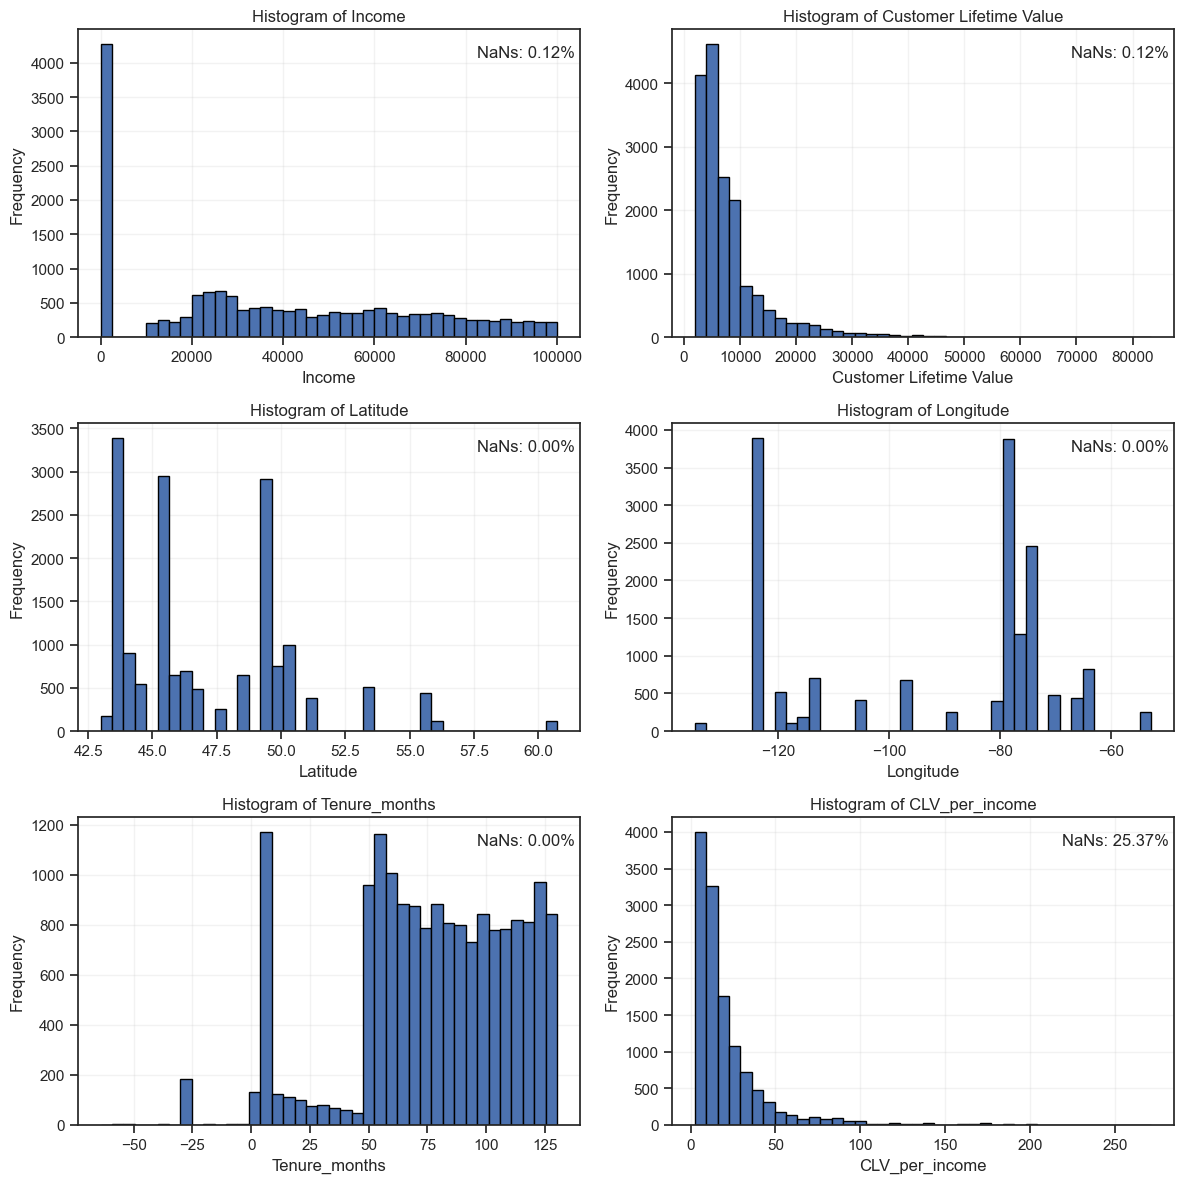

In [526]:
plot_histograms_side_by_side(customers_db, metric_features, bins=40)

**Income:** Two groups stand out: one at exactly 0, and another spread mostly between 15k and 100k. It is expected very different behaviors for the zero-income group vs. the positive-income bulk.

**Customer Lifetime Value:** Strongly right-skewed; most customers fall between ~2k–10k, the median sits in the mid-5k range, and a long, sparse tail stretches into high tens of thousands, indicating a small elite segment driving outsized value.

**Latitude:** Within Canadian bounds (~43°–61°N), with pronounced peaks near ~43–45° and ~49–50°, matching major population corridors (Southern ON/QC and BC).

**Longitude:** Distinct east/west clusters around ~−123 (BC coast) and ~−80 (ON/QC), plus lighter presence across the prairies; geography is strongly hub-concentrated.

**Tenure_months:** Most customers sit between 50 and 125 months (4–10 years), with a pronounced bump around 55–60 months, which is consistent with a large 2018–2019 enrollment cohort. There’s a small recent cohort in the 0–30 month range.

**CLV_per_income:** Highly right-skewed ratio; the bulk sits at low fractions (often <0.3), with a long tail of customers for whom captured value is large relative to income. 

##### 1.1.6.1.2. Non-Metric Features:

In [527]:
def plot_bar_chart_top15(
    df: pd.DataFrame,
    cols: list[str],
    ncols: int = 2,
    figsize_per_row: tuple = (12, 4),
    rotate_xticks: int = 30,
):

    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    total_rows = len(df)

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype("string")  
        counts = s.value_counts(dropna=False)    
        counts_plot = counts.iloc[:15]          

        categories = counts_plot.index.tolist()
        values = counts_plot.values

        ax.bar(categories, values, edgecolor="black")
        ax.set_title(f"{col} (Top-15)")
        ax.set_ylabel("Count")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")

        # Annotate percentage:
        for x, v in enumerate(values):
            pct = (v / total_rows * 100) if total_rows else 0
            ax.text(x, v, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

        # Annotate NaNs percentage:
        nan_pct = s.isna().mean() * 100
        ax.text(0.99, 0.95, f"NaNs: {nan_pct:.2f}%", transform=ax.transAxes, ha="right", va="top", fontsize=9)

    # Remove empty axis for odd number of variables:
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


C:\Users\marta\AppData\Local\Temp\ipykernel_3132\2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
C:\Users\marta\AppData\Local\Temp\ipykernel_3132\2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
C:\Users\marta\AppData\Local\Temp\ipykernel_3132\2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")
C:\Users\marta\AppData\Local\Temp\ipykernel_3132\2259423745.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtic

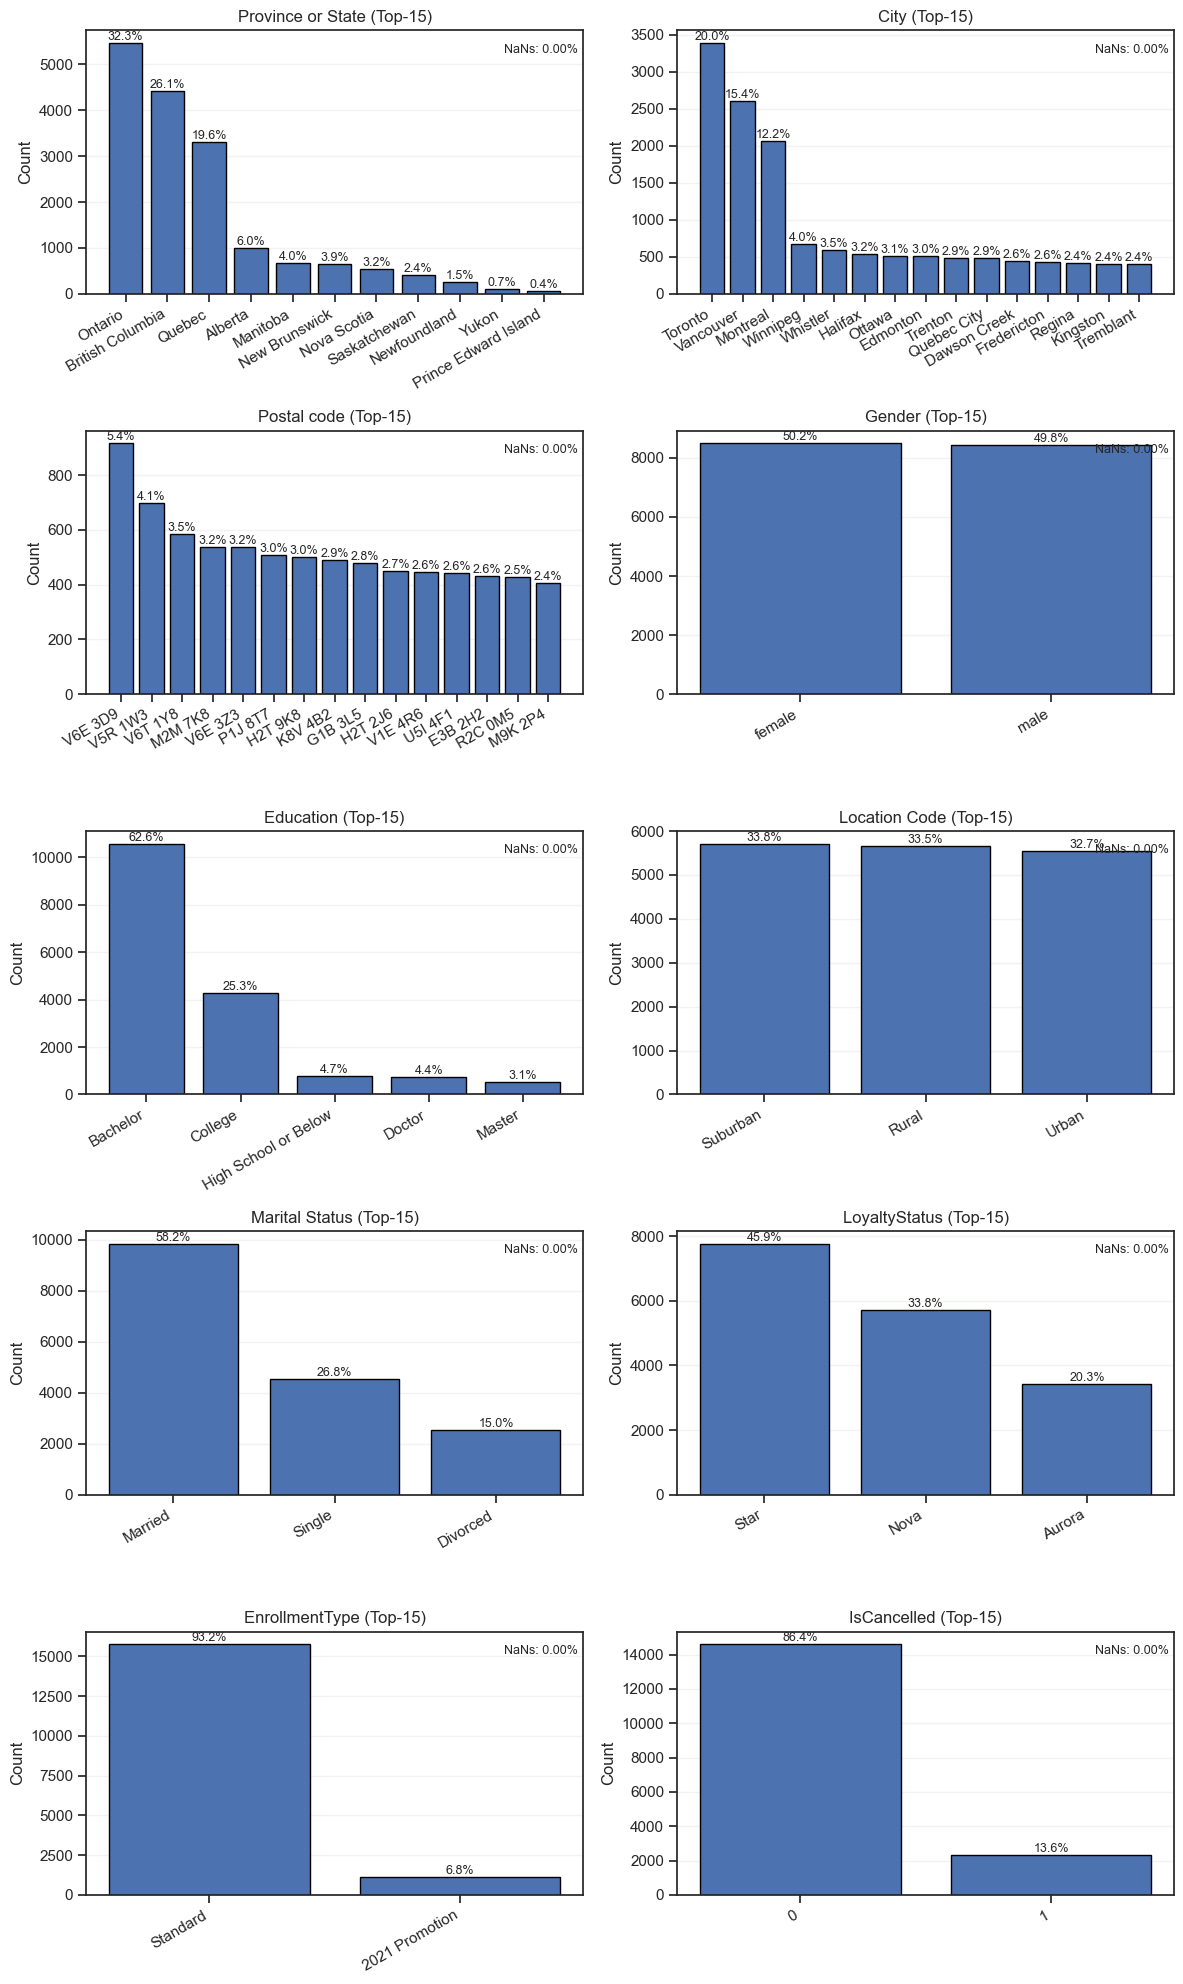

In [528]:
plot_bar_chart_top15(customers_db, non_metric_features, ncols=2, rotate_xticks=30)

**Province or State:** Highly concentrated in Ontario (~32%), followed by British Columbia (~26%) and Quebec (~20%); the rest of the provinces each contribute small shares.

**City:** Dominated by big hubs—Toronto (~20%), Vancouver (~15%), Montreal (~12%)—with a long tail of smaller cities each below ~4%.

**Postal code:** A few codes carry large shares (top code ~5.4%, next ~4.1%), indicating area-level coding rather than household-level granularity.

**Gender:** Essentially balanced, with female ~50.2% and male ~49.8%.

**Education:** Strong skew to Bachelor (~62.6%), then College (~25.3%); advanced degrees and “High School or Below” are small minorities.

**Location Code:** Fairly even split across Suburban (~33.8%), Rural (~33.5%), and Urban (~32.7%), with a slight suburban tilt.

**Marital Status:** Majority Married (~58%), with Single (~27%) and Divorced (~15%) making up the rest.

**LoyaltyStatus:** Tier mix leans to Star (~46%), then Nova (~34%), with Aurora (~20%) as the smallest tier.

**EnrollmentType:** Heavily dominated by Standard (~93%); 2021 Promotion (~7%) is a much smaller cohort.

**IsCancelled:** Vast majority active (~94.6%), with cancelled (~5.4%) representing a small minority

## Outliers:

In [529]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

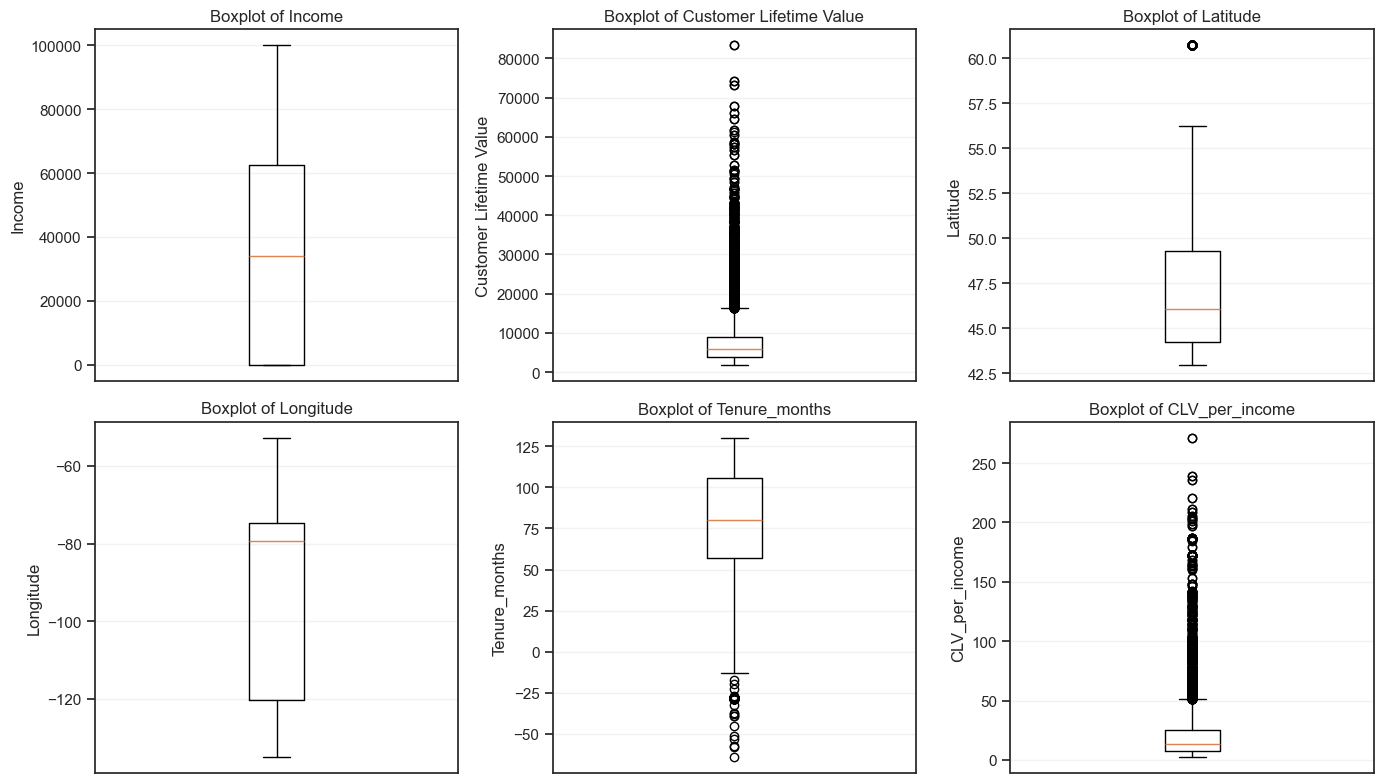

In [530]:
boxplot_grid(customers_db, metric_features, ncols=3, figsize=(14, 8), showfliers=True)

**Income:** 
- The boxplot shows a low median around 33–35k, with the lower quartile pressed near 0 and an IQR that stretches into the 60k range. Right-skew distribution. Whiskers extend far upward with many individual dots beyond, confirming a long upper tail up to ~100k.
- Outliers: Two types of outliers identified: 
    - A mass at 0 (could be true zero income or a placeholder) 
    - High earners in the 90th–99th percentiles. 

**Customer Lifetime Value:**
- The median is modest (~5–6k) and the IQR is relatively tight, but the whiskers are short compared to a dense cloud of high outliers reaching >80k. Strong right-skew distribution where a small fraction drives outsized value.
- Outliers: Top-percentile customers might be potential VIPs rather than errors.

**Latitude:**
- Center of the box lies in the mid-40s, with moderate spread; whiskers are short and only a few dots sit above ~61°N. Distribution is tight and plausible for Canada.
Outliers & actions: The high points likely reflect northern communities.

**Longitude:**
- Median sits near −80, with an IQR that spans from −120 to −75. Dots beyond whiskers toward −135 and −55 reflect west coast and Atlantic extremes. Shape is broad but geographically coherent.
- Outliers: Valid geographic spread. 

**Tenure_months:**
- Median around 80–85 months (~6–7 years) with a wide IQR into the 100+ months range, indicating many long-standing customers. The lower tail shows negative values and a small cluster just below zero (temporal inconsistencies).
- Outliers: Negative tenures are invalid.

**CLV_per_income:**
- Central tendency is low (~0.1–0.2), IQR is narrow, and there’s a pronounced right tail with ratios well >1. This tells us that most customers contribute modest value relative to income, while a minority show lower ratio.
- Outliers: Very high ratios often occur when income is tiny/zero or tenure is short. 

### Multivariate Analysis:

### Numerical x Numerical features:

In [531]:
def plot_pairwise_numeric(df, metric_features, title="Pairwise Relationship of Numerical Variables"):
    # Style and grid:
    sns.set_theme(style="ticks", rc={
        "axes.grid": True,
        "grid.color": ".9",
        "grid.linestyle": "-",
        "axes.spines.right": False,
        "axes.spines.top": False,
    })

    g = sns.pairplot(
        data=df[metric_features],
        diag_kind="hist",
        height=3.2,       
        aspect=1.0,
        corner=False,
        plot_kws=dict(
            s=14,         
            alpha=0.45,   
            linewidth=0.25,
            edgecolor="black",  
            rasterized=True     
        ),
        diag_kws=dict(
            bins=30,
            edgecolor="black",
            linewidth=0.2
        )
    )

    g.fig.suptitle(title, fontsize=18, y=1.02)
    plt.show()
    return g


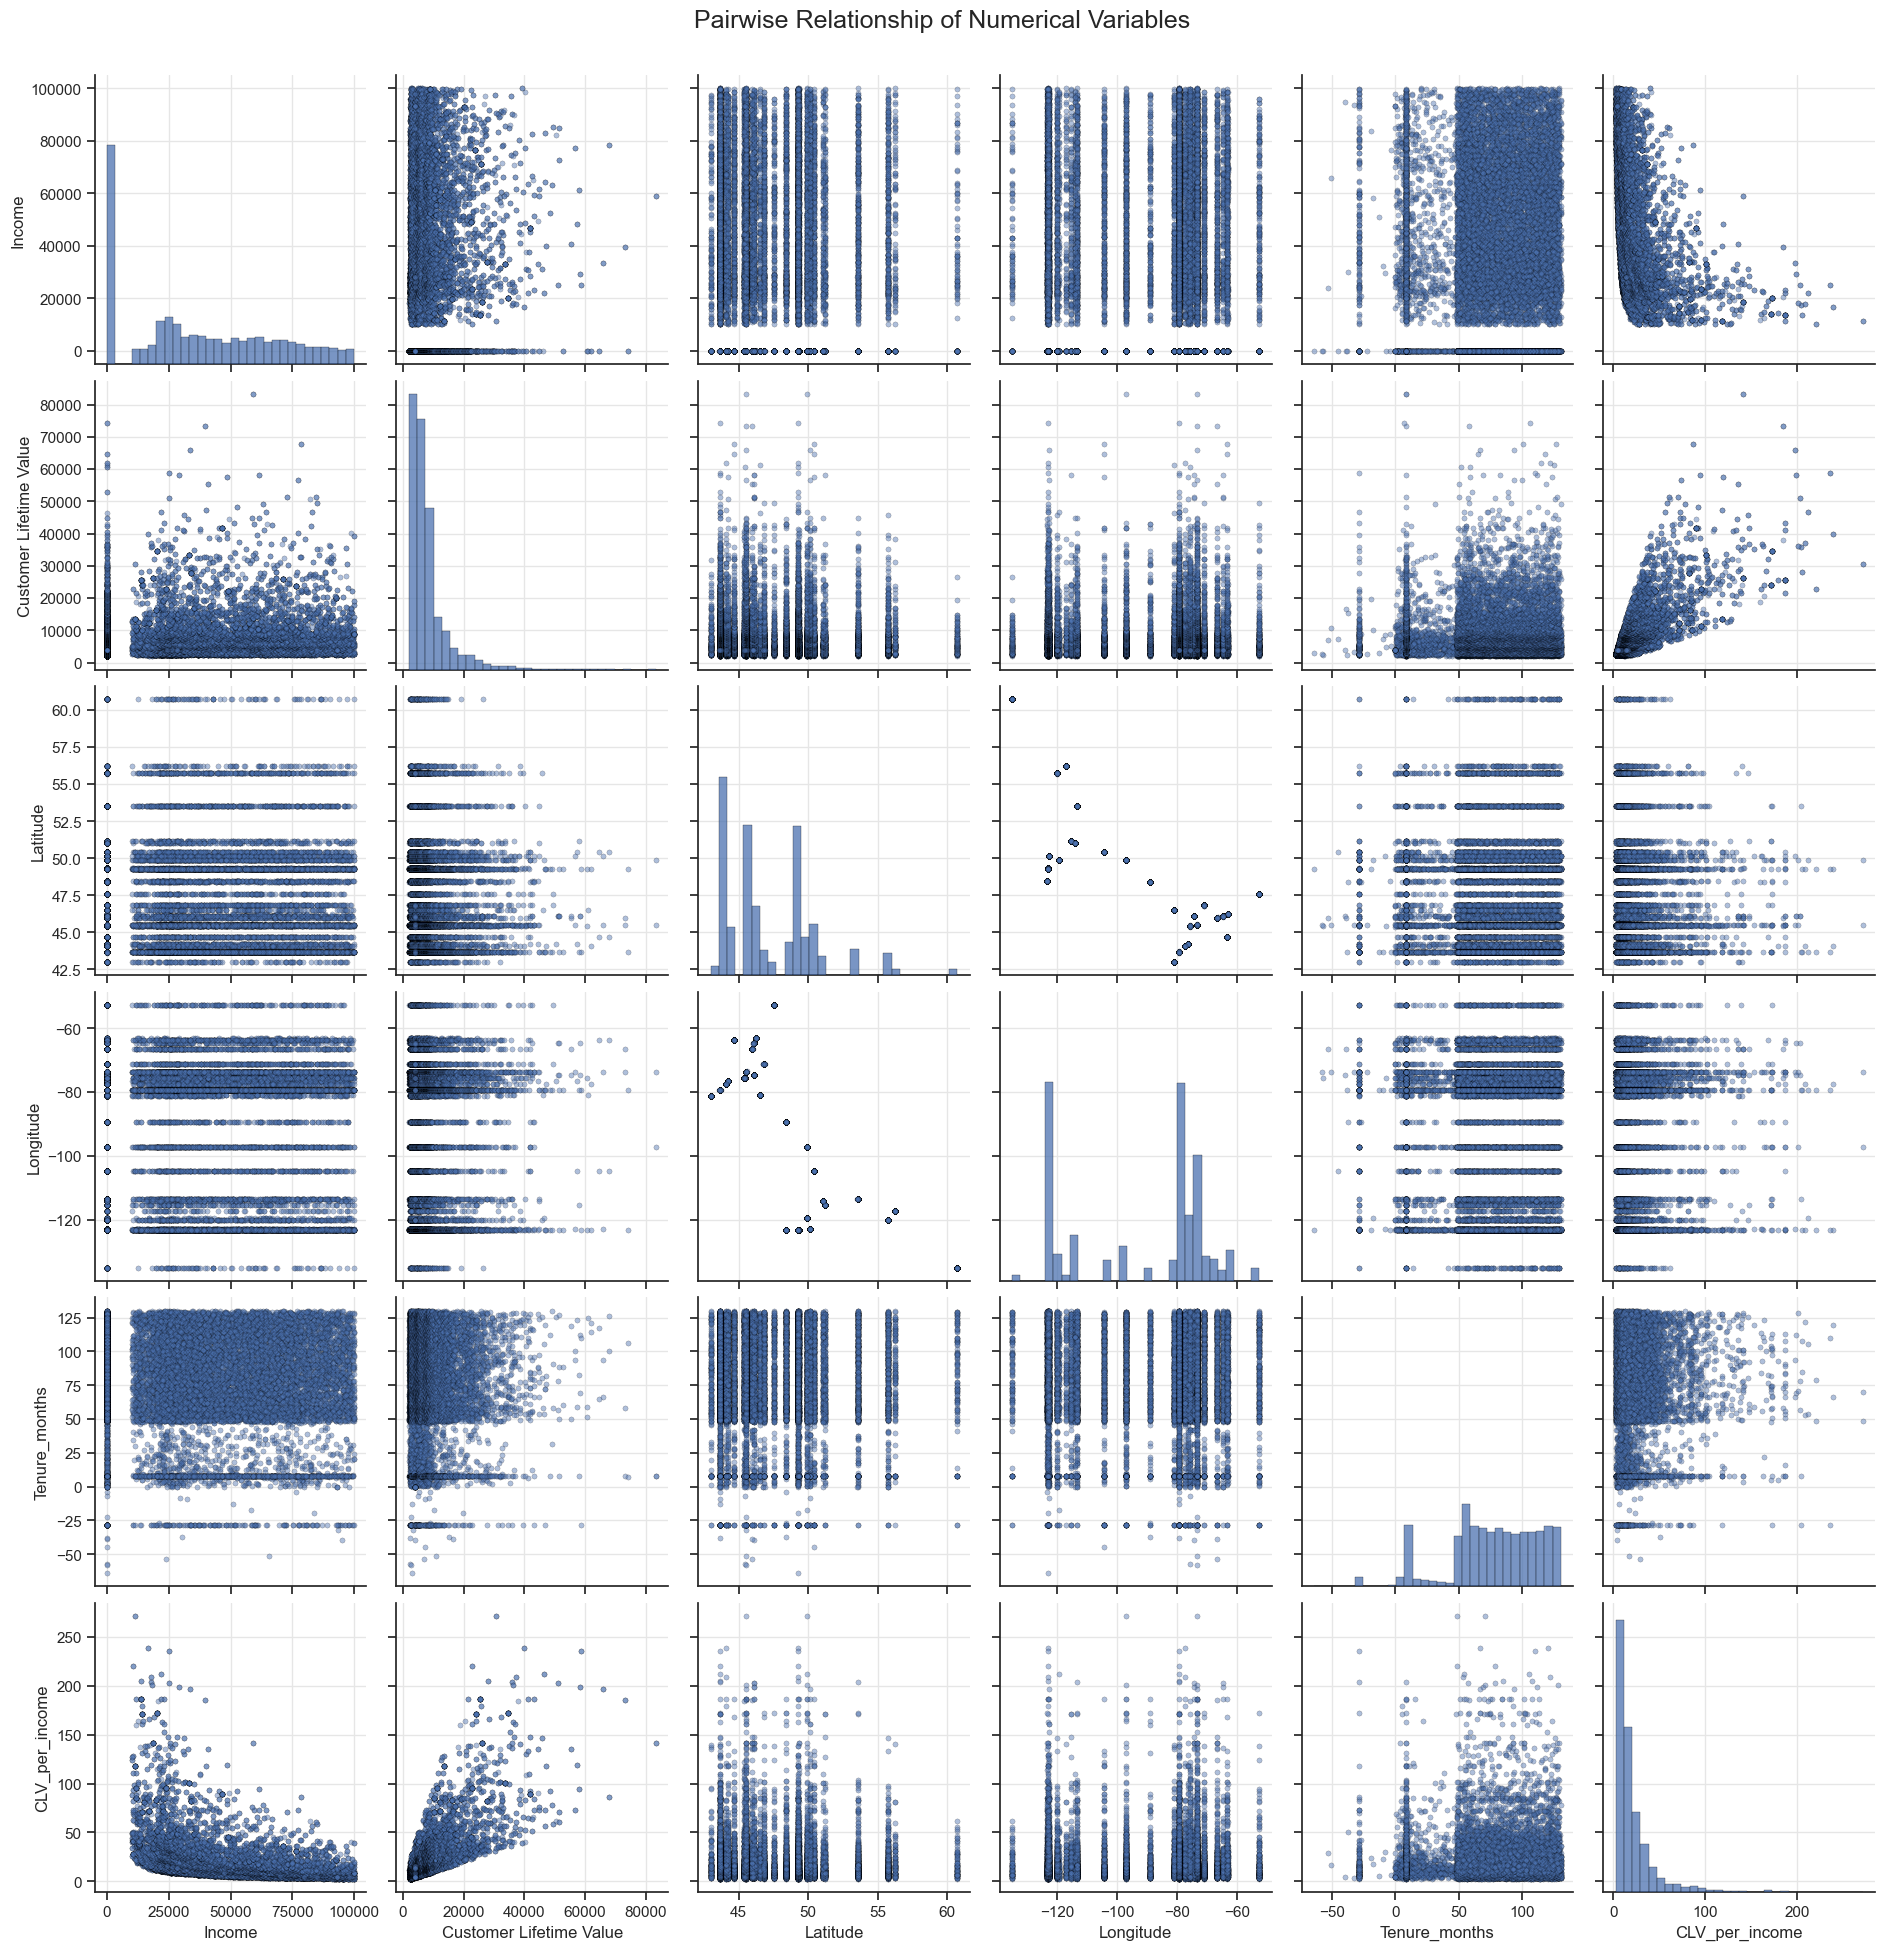

In [532]:
plot_pairwise_numeric(customers_db, metric_features)

**CLV vs Income:** Weak positive trend. High CLV occurs across the whole income range. Lots of spread, income alone does not order CLV well.

**CLV vs Tenure_months:** Non-linear pattern. CLV rises quickly for early tenure and seems to plateau; broad vertical spread at any given tenure (cohort effect).

**Income vs Tenure_months:** No monotonic relationship. The tenure band 50–125m has income spread wide, plus the vertical line at Income=0.

**CLV_per_income vs Tenure_months:** Most ratios remain low across tenure with a few high spikes tied to low income.

### Correlation matrix:

In [533]:
def plot_corr_heatmap(df, metric_features, method):
    
    fig = plt.figure(figsize=(10, 8)) 
    corr = df[metric_features].corr(method)
    sns.heatmap(data=corr, annot=True, )

    plt.show()

#### Pearson:

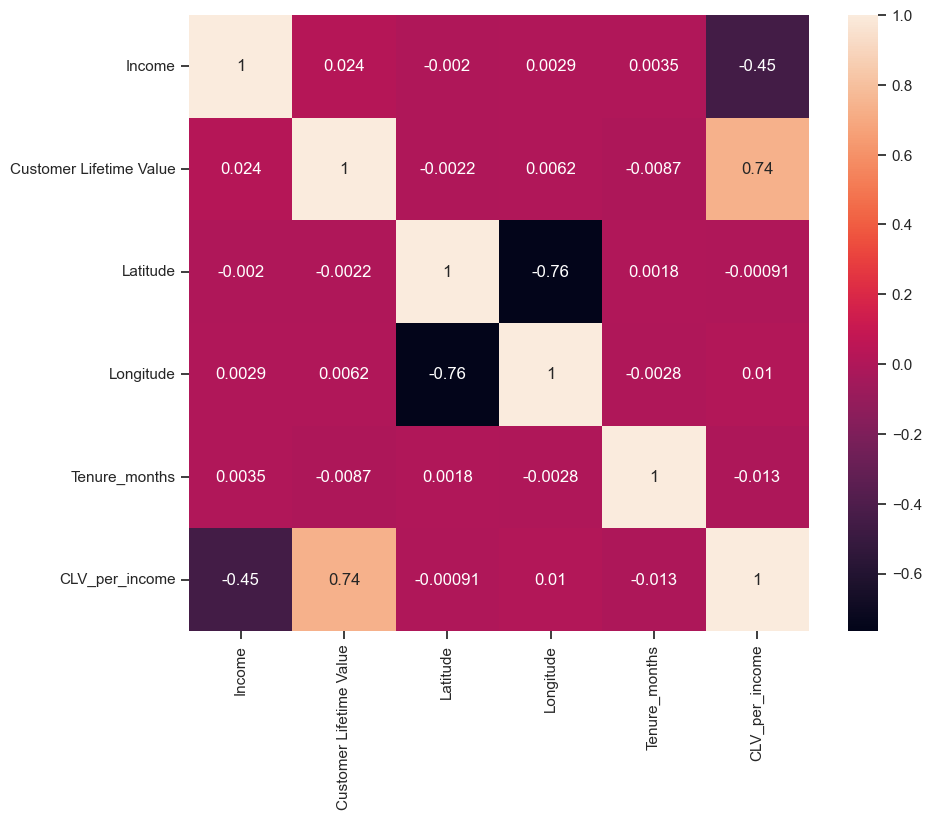

In [534]:
plot_corr_heatmap(customers_db, metric_features, method="pearson")

CLV_per_income and CLV, Income
- Strong positive correlation, as expected. Redundant features.

Geography: Latitude, Longitude: −0.76 (strong negative)
- Reflects Canada’s SW–NE population band.

Near-zero relationships (little linear structure)
- CLV ↔ Income: +0.024 (very weak)
    - Customer value is only very weakly ordered by declared income; high-CLV customers exist across income levels. Income alone isn’t a strong linear driver of CLV.

- Tenure_months with CLV (−0.0087), Income (+0.0035), CLV_per_income (−0.013): ~0:
    - No linear trend. Any tenure effects are likely nonlinear.

- Latitude/Longitude with CLV or Income: ~0 
    - Raw coordinates show no linear association with value or income at the national scale; if geography matters, it’s via regional groupings (province/city) rather than raw lat/lon.

#### Spearman:

Handles skewness and outliers better than Pearson:

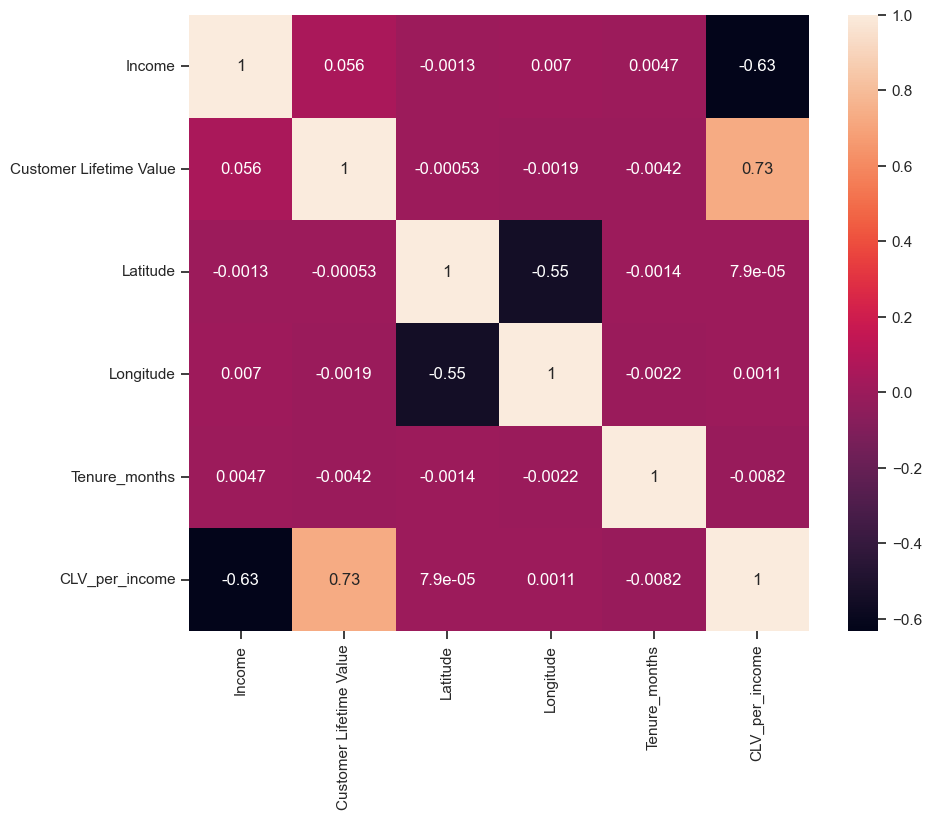

In [535]:
plot_corr_heatmap(customers_db, metric_features, method="spearman")

**CLV_per_income and CLV, Income**:
- Strong positive correlation, as expected. Redundant features. 

**Geography - Latitude, Longitude: −0.55 (moderate negative correlation):**
- Canada’s populated band runs SW–NE; as longitude increases (less negative, moving east), latitude generally decreases a bit—hence a negative monotonic relation.

**Near-zero relationships:**
- CLV, Income: +0.056 (very weak)
    - Customer value is only weakly ordered by declared income. High-CLV customers exist across income levels. Income alone isn’t a strong driver of value.

- Tenure_months with CLV (+0.003), Income (+0.004), CLV_per_income (−0.005): ~0:
    - Little monotonic pattern overall.

- Latitude/Longitude with CLV/Income: ~0
    - No clear rank trend between value/income and raw coordinates.

**Despite correlation values are not exactly the same between Spearman and Pearson, main conclusions overlap.**

### Categorical x Categorical features:

In [536]:
def plot_stacked_bars_grid(
    df,
    features,                    
    stack_by="IsCancelled",      
    ncols=2,
    top_n=12,                    
    normalize=True,             
    figsize_per_row=(12, 4),
    rotate_xticks=30
):
    # figure grid
    n = len(features)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1]*nrows))
    axes = np.atleast_1d(axes).ravel()

    # stack order - sorted by frequency
    stack_levels = df[stack_by].astype("string").value_counts(dropna=False).index.tolist()

    for i, col in enumerate(features):
        ax = axes[i]
        s = df[col].astype("string").str.strip()

        # Keep top-N categories + 'Other'
        vc = s.value_counts(dropna=False)
        if top_n and len(vc) > top_n:
            top_vals = set(vc.head(top_n).index)
            s = s.where(s.isin(top_vals), "Other")

        # crosstab
        ct = pd.crosstab(s, df[stack_by].astype("string"), dropna=False).reindex(columns=stack_levels, fill_value=0)
        ct = ct.sort_values(ct.columns.tolist(), ascending=False)

        # normalize to percentages:
        if normalize:
            pct = ct.div(ct.sum(axis=1), axis=0).fillna(0) * 100
            plot_df = pct
            ylabel = "Percent"
        else:
            plot_df = ct
            ylabel = "Count"

        # plot stacked bars
        bottoms = np.zeros(len(plot_df))
        x = np.arange(len(plot_df.index))
        for lvl in plot_df.columns:
            vals = plot_df[lvl].values
            ax.bar(x, vals, bottom=bottoms, label=str(lvl))
            bottoms += vals

        # labels:
        ax.set_title(f"{col} × {stack_by}")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df.index, rotation=rotate_xticks, ha="right")
        ax.grid(axis="y", alpha=0.25)

        # annotate percentages on the bars:
        if normalize:
            for xi in x:
                y0 = 0
                for lvl in plot_df.columns:
                    v = plot_df.loc[plot_df.index[xi], lvl]
                    if v >= 5:  
                        ax.text(xi, y0 + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=8)
                    y0 += v

    # legend:
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=stack_by, loc="upper center", ncol=min(len(labels), 5), frameon=False, bbox_to_anchor=(0.5, 1.02))

    # remove unused axes:
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



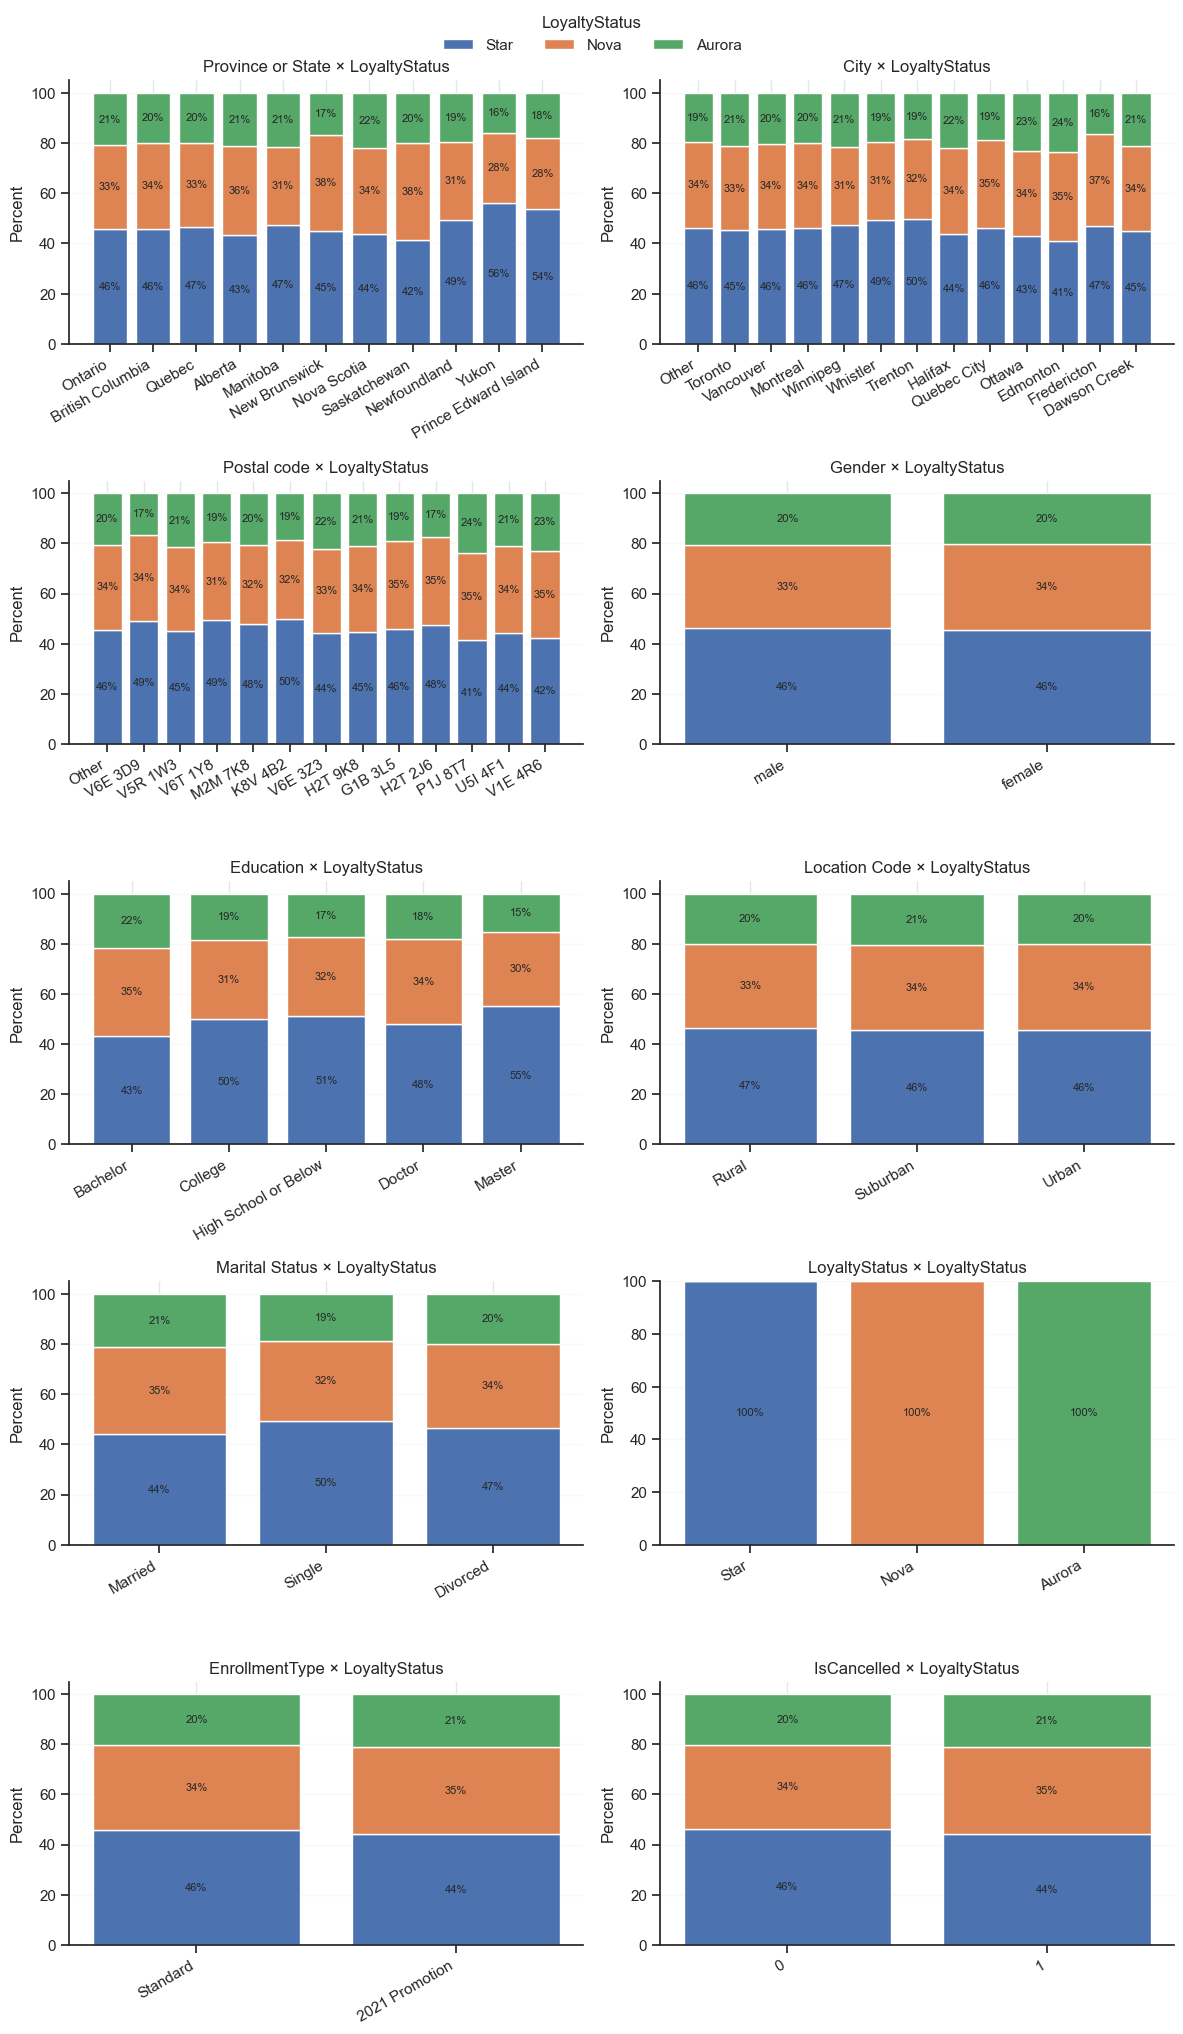

In [537]:
plot_stacked_bars_grid(
    customers_db,
    features=non_metric_features,
    stack_by="LoyaltyStatus",   
    ncols=2,
    top_n=12,                 
    normalize=True
)

**Loyalty status does not appear to be meaningfully segmented by geography. We can conclude that LoyaltyStatus (Star, Nova, Aurora) does not vary significantly across segments.**

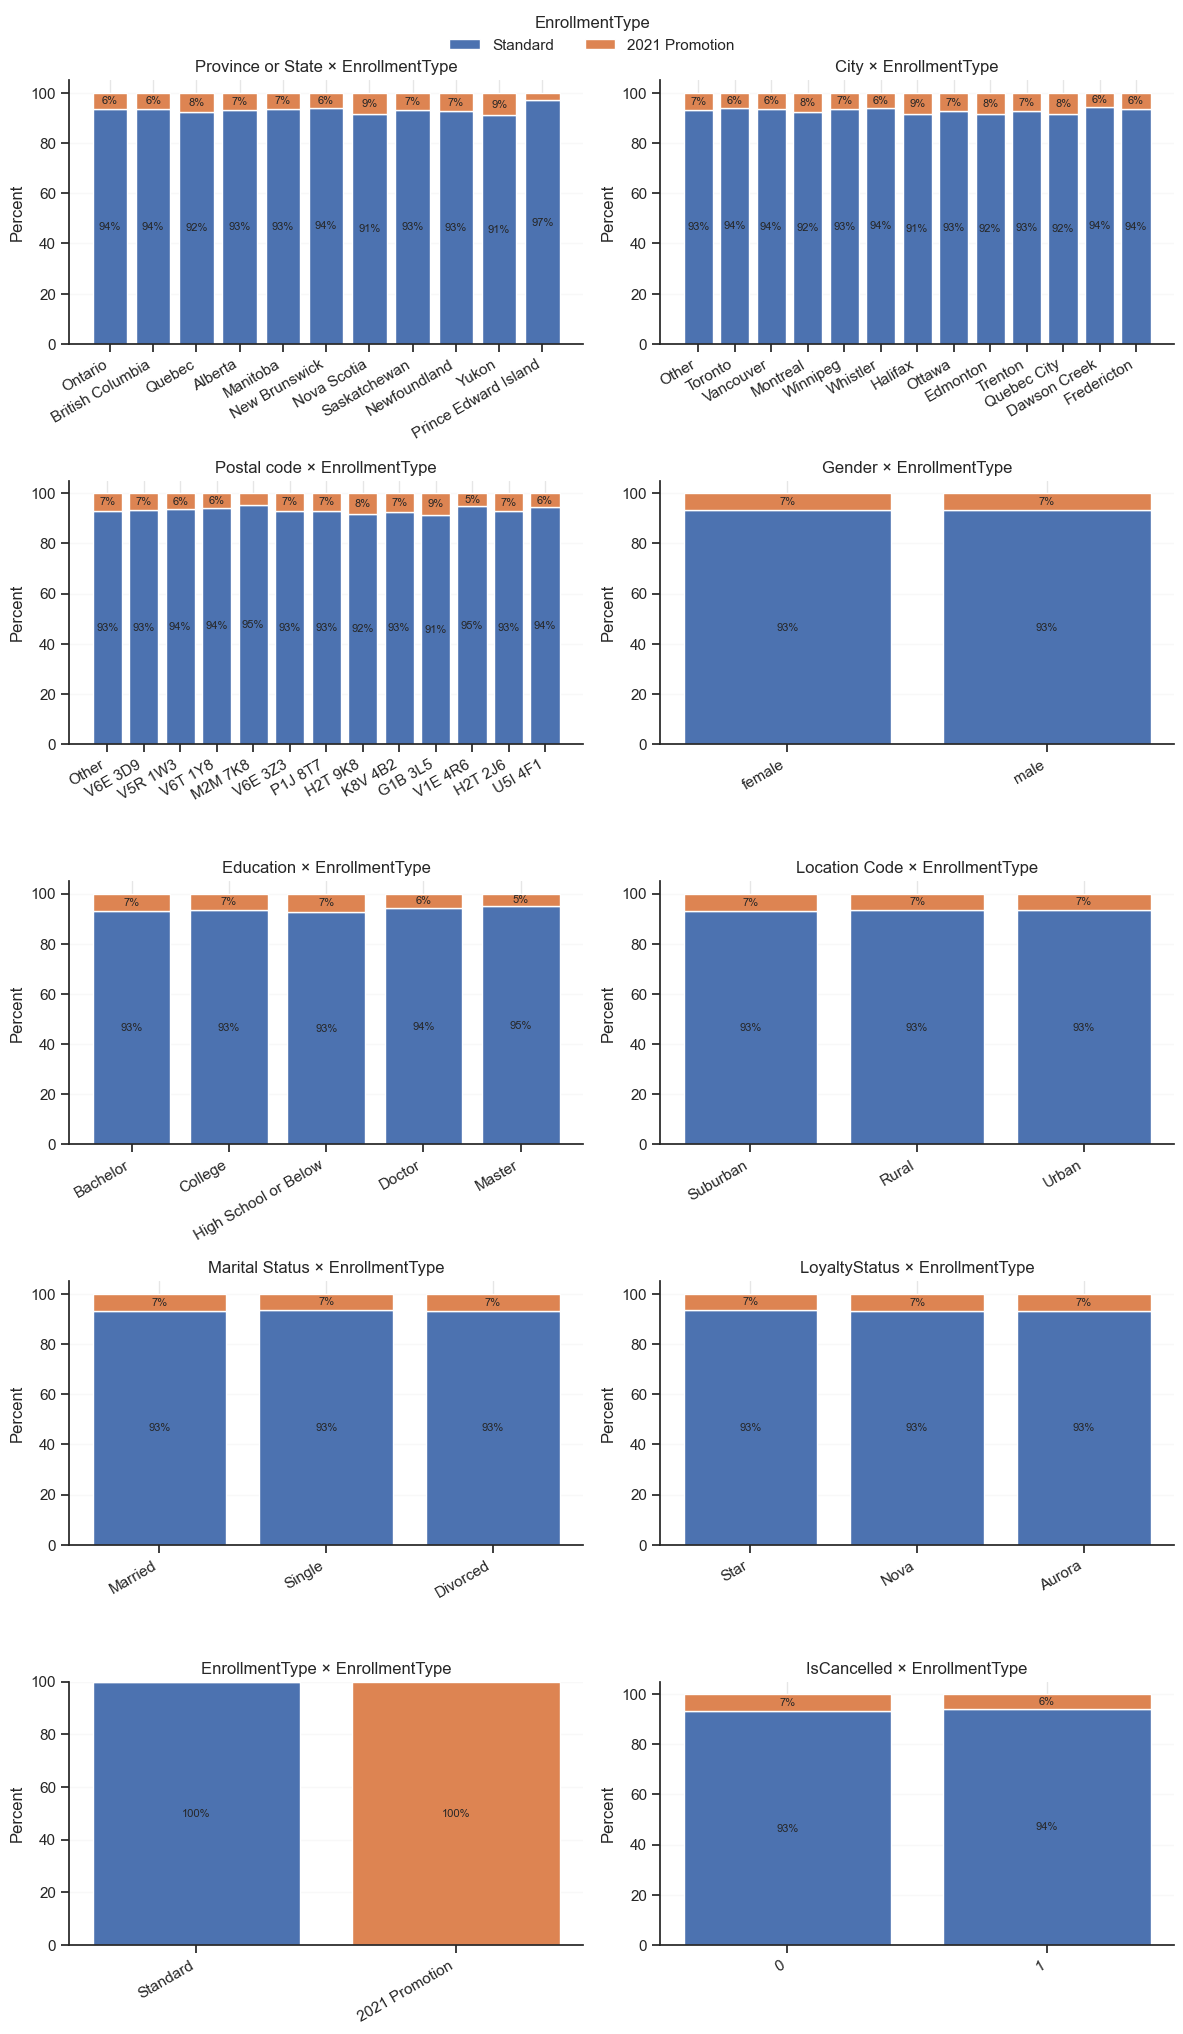

In [538]:
plot_stacked_bars_grid(
    customers_db,
    features=non_metric_features,
    stack_by="EnrollmentType",   
    ncols=2,
    top_n=12,                 
    normalize=True
)

**Enrollment type does not appear to be meaningfully segmented by geography. We can conclude that EnrollmentType (Standard vs 2021 Promotion) does not vary across segments.**

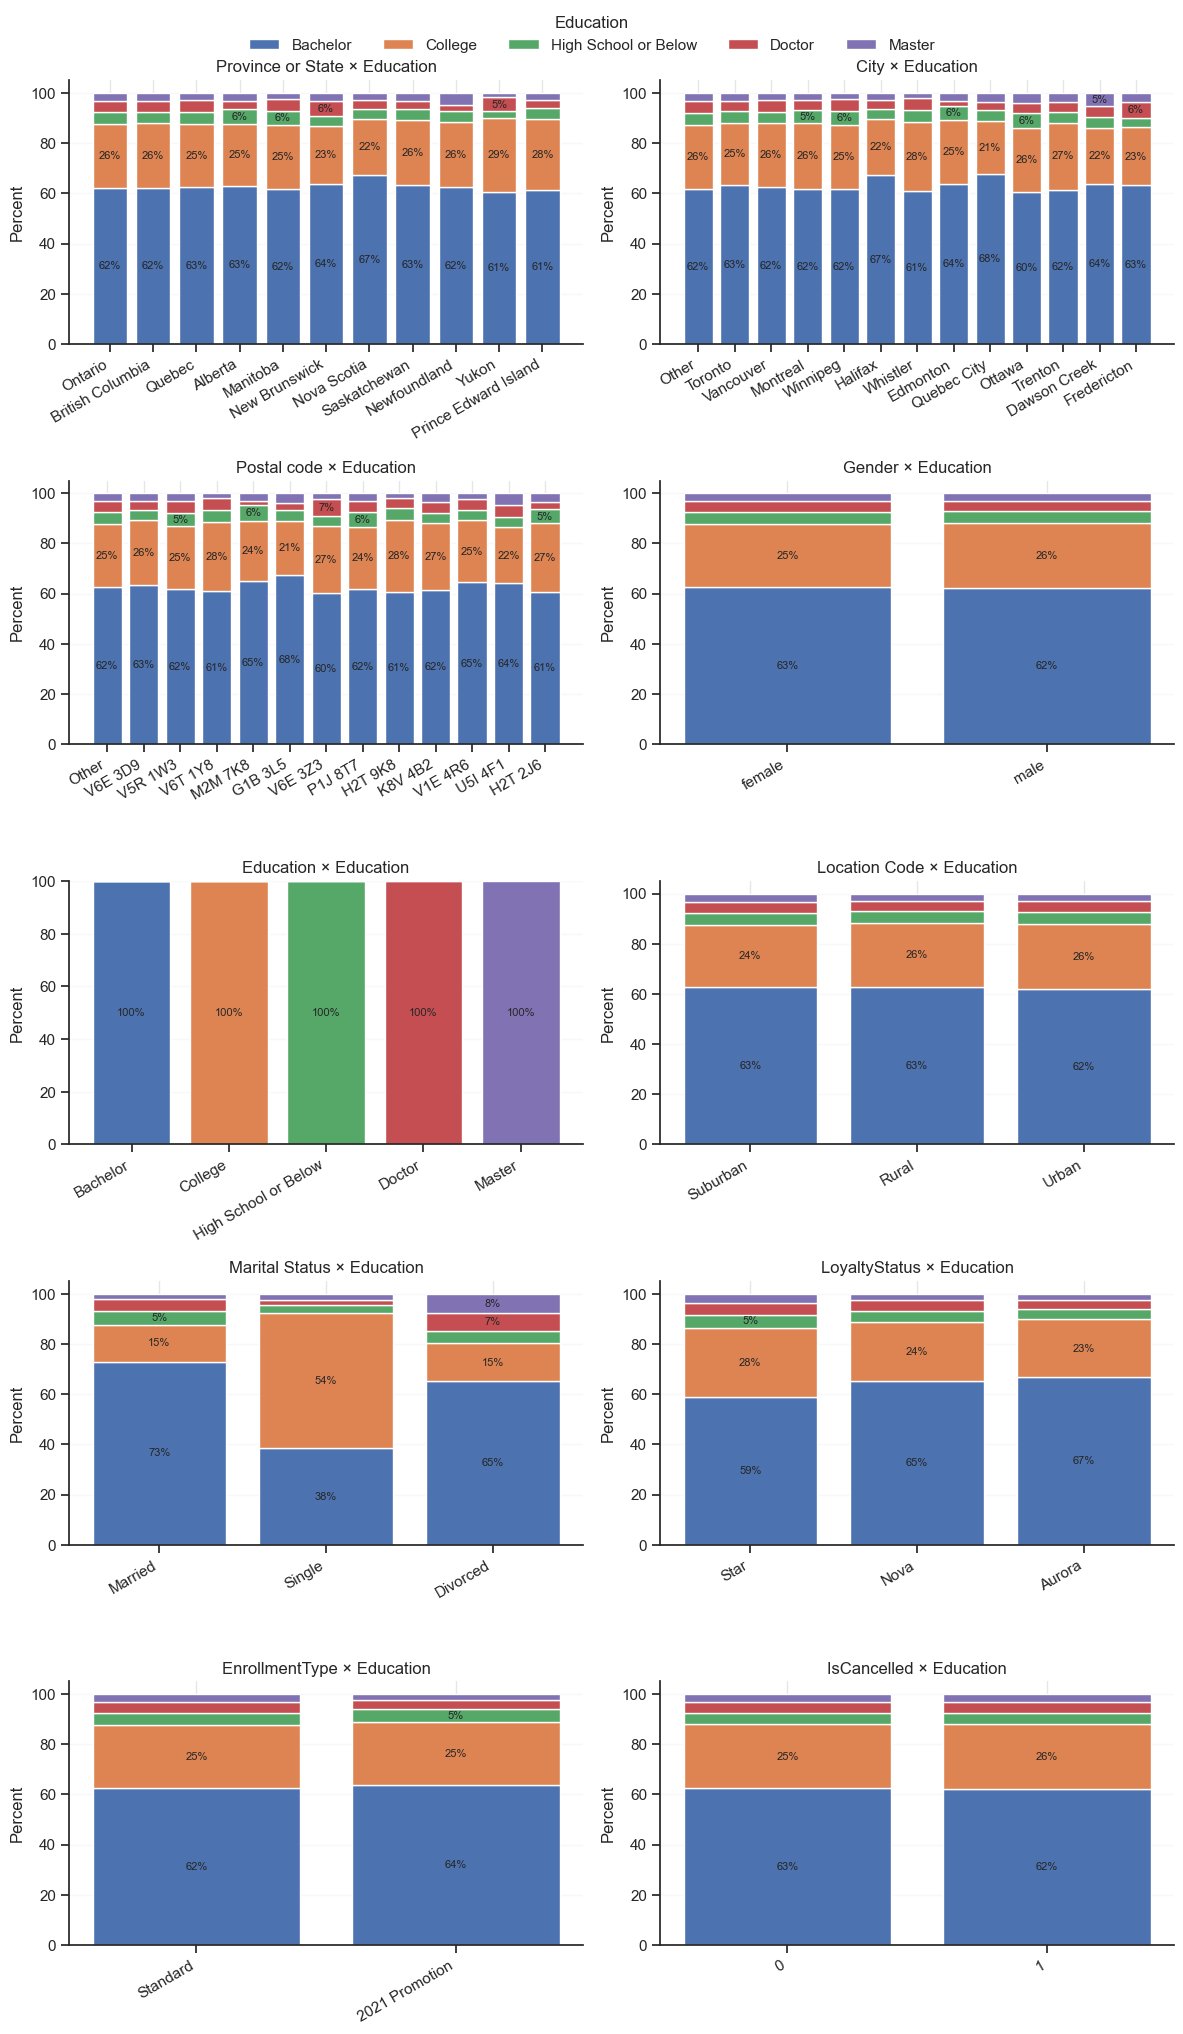

In [539]:
plot_stacked_bars_grid(
    customers_db,
    features=non_metric_features,
    stack_by="Education",   
    ncols=2,
    top_n=12,                 
    normalize=True
)

**Education x MaritalStatus:**
- Marital status is associated with education mix: Single leans College (~54%) with lower Bachelor (~38%). Married has higher Bachelor (~73%); Divorced sits between (~65% Bachelor). 

**We can conclude that, apart from marital status, Education does not vary significantly across segments nor geographies.**

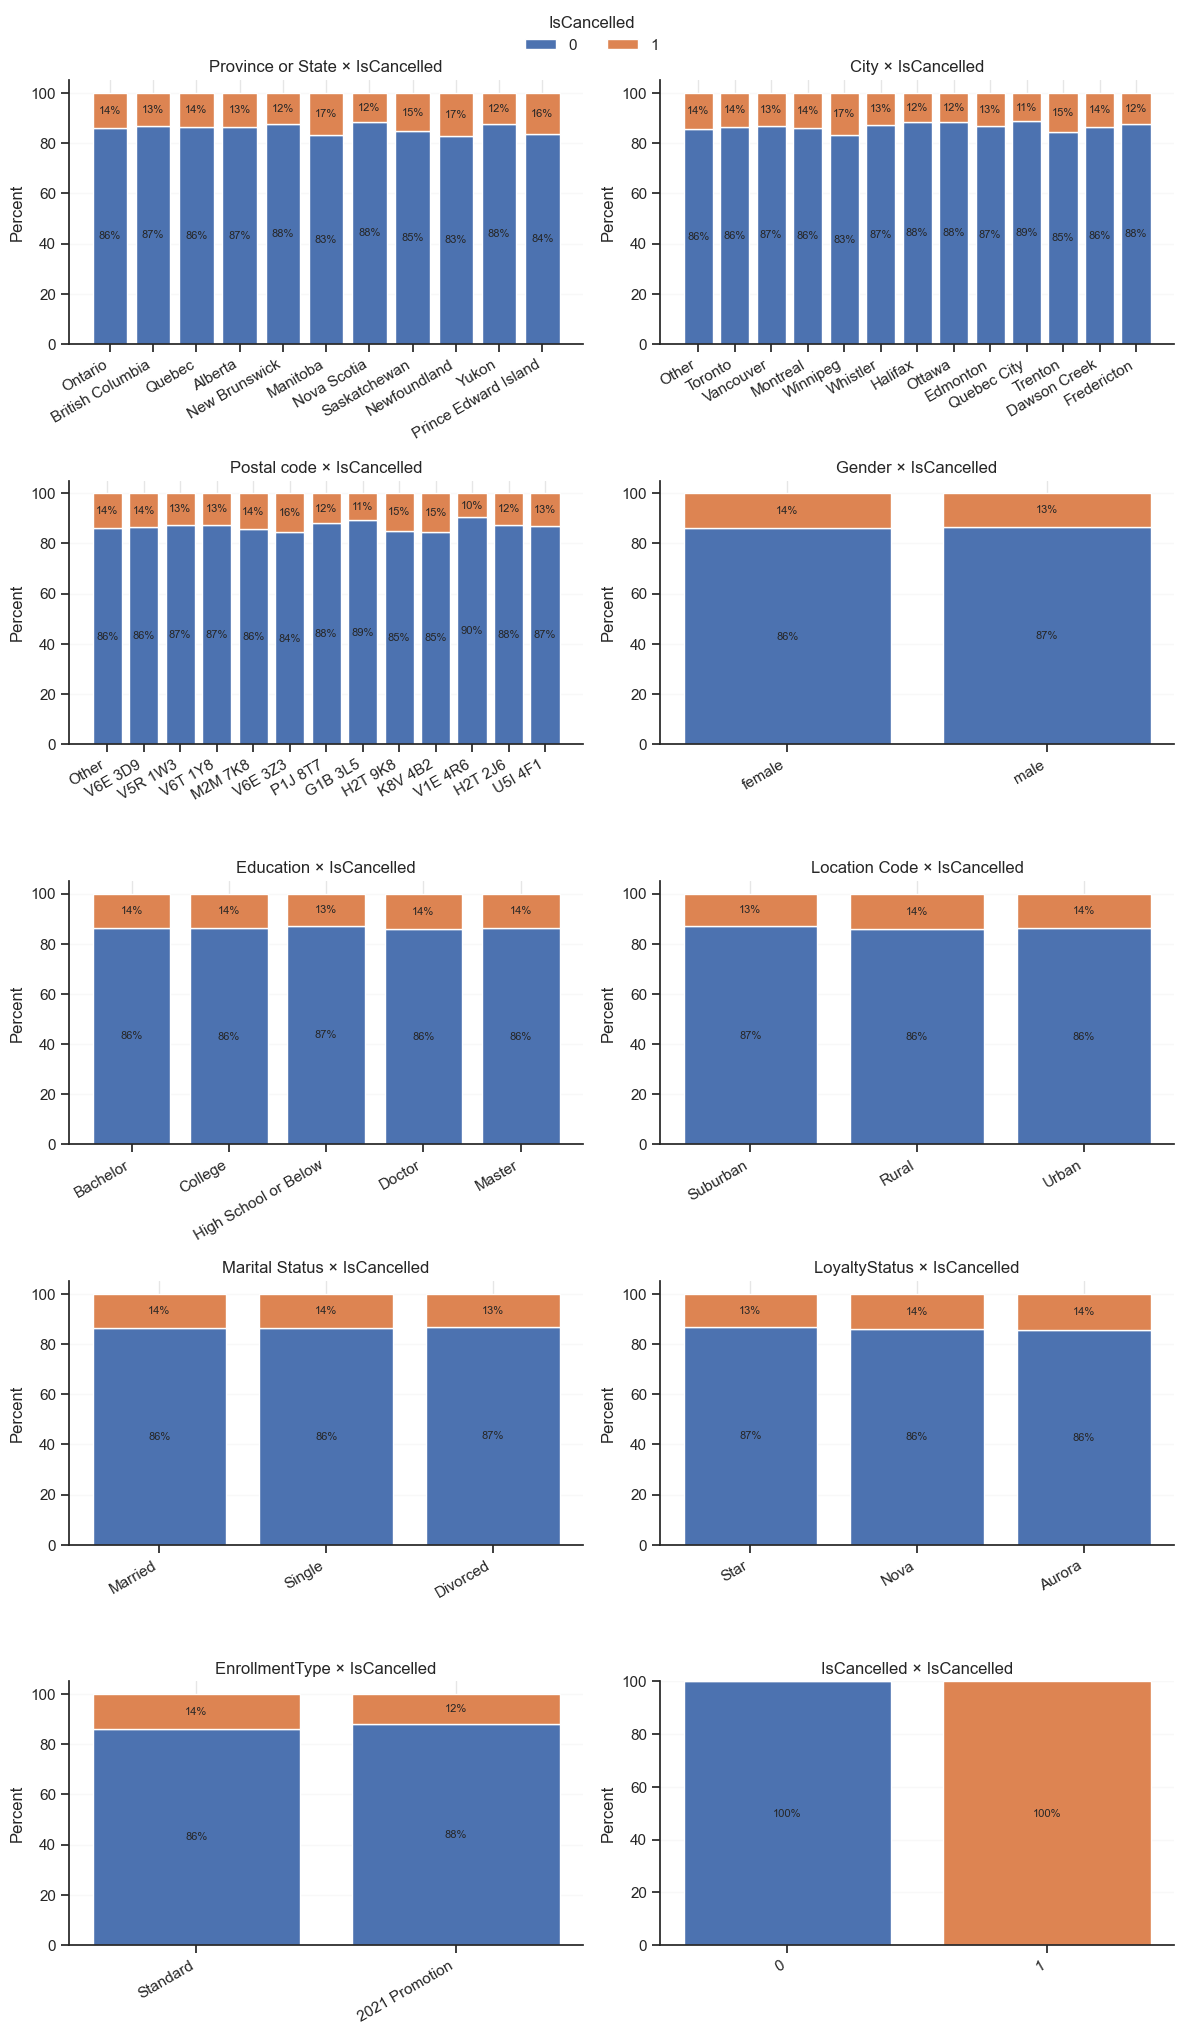

In [540]:
plot_stacked_bars_grid(
    customers_db,
    features=non_metric_features,
    stack_by="IsCancelled",   
    ncols=2,
    top_n=12,                 
    normalize=True
)

**We can conclude that cancellation rate does not vary significantly across segments nor geographies**

### Numerical x Categorical features:

In [541]:
def plot_hist_by_categories(
    df: pd.DataFrame,
    numeric_col: str,
    cat_cols: list[str],
    ncols: int = 2,
    bins: int | str = 40,
    stat: str = "density",
    element: str = "step",
    alpha: float = 0.35,
    figsize_per_row: tuple = (12, 4),
    title_prefix: str = "Histogram of",
):

    sns.set_theme(style="ticks")

    # Common bins from the numeric column
    x = pd.to_numeric(df[numeric_col], errors="coerce")
    x = x[np.isfinite(x)]
    bin_edges = np.histogram_bin_edges(x, bins=bins)

    n = len(cat_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows)
    )
    axes = np.atleast_1d(axes).ravel()

    for i, cat in enumerate(cat_cols):
        ax = axes[i]

        if cat not in df.columns:
            ax.axis("off")
            continue

        # Determine Top-10 categories (excluding NaN)
        vc = df[cat].dropna().value_counts()
        top_classes = vc.head(10).index

        # Keep only rows in Top-10 and with finite numeric values
        tmp = df.loc[df[cat].isin(top_classes)].copy()
        tmp[numeric_col] = pd.to_numeric(tmp[numeric_col], errors="coerce")
        tmp = tmp[np.isfinite(tmp[numeric_col])]

        # Order in legend by frequency:
        hue_order = list(top_classes)

        sns.histplot(
            data=tmp,
            x=numeric_col,
            hue=cat,
            hue_order=hue_order,
            bins=bin_edges,
            element=element,
            stat=stat,
            common_bins=True,
            alpha=alpha,
            ax=ax,
        )

        ax.set_title(f"{title_prefix} {numeric_col} by {cat} (Top 10 only)")
        ax.grid(alpha=0.25)
        ax.set_xlabel(numeric_col)
        ax.set_ylabel(stat.capitalize())

    # Hide any unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


#### Customer Lifetime Value by category:

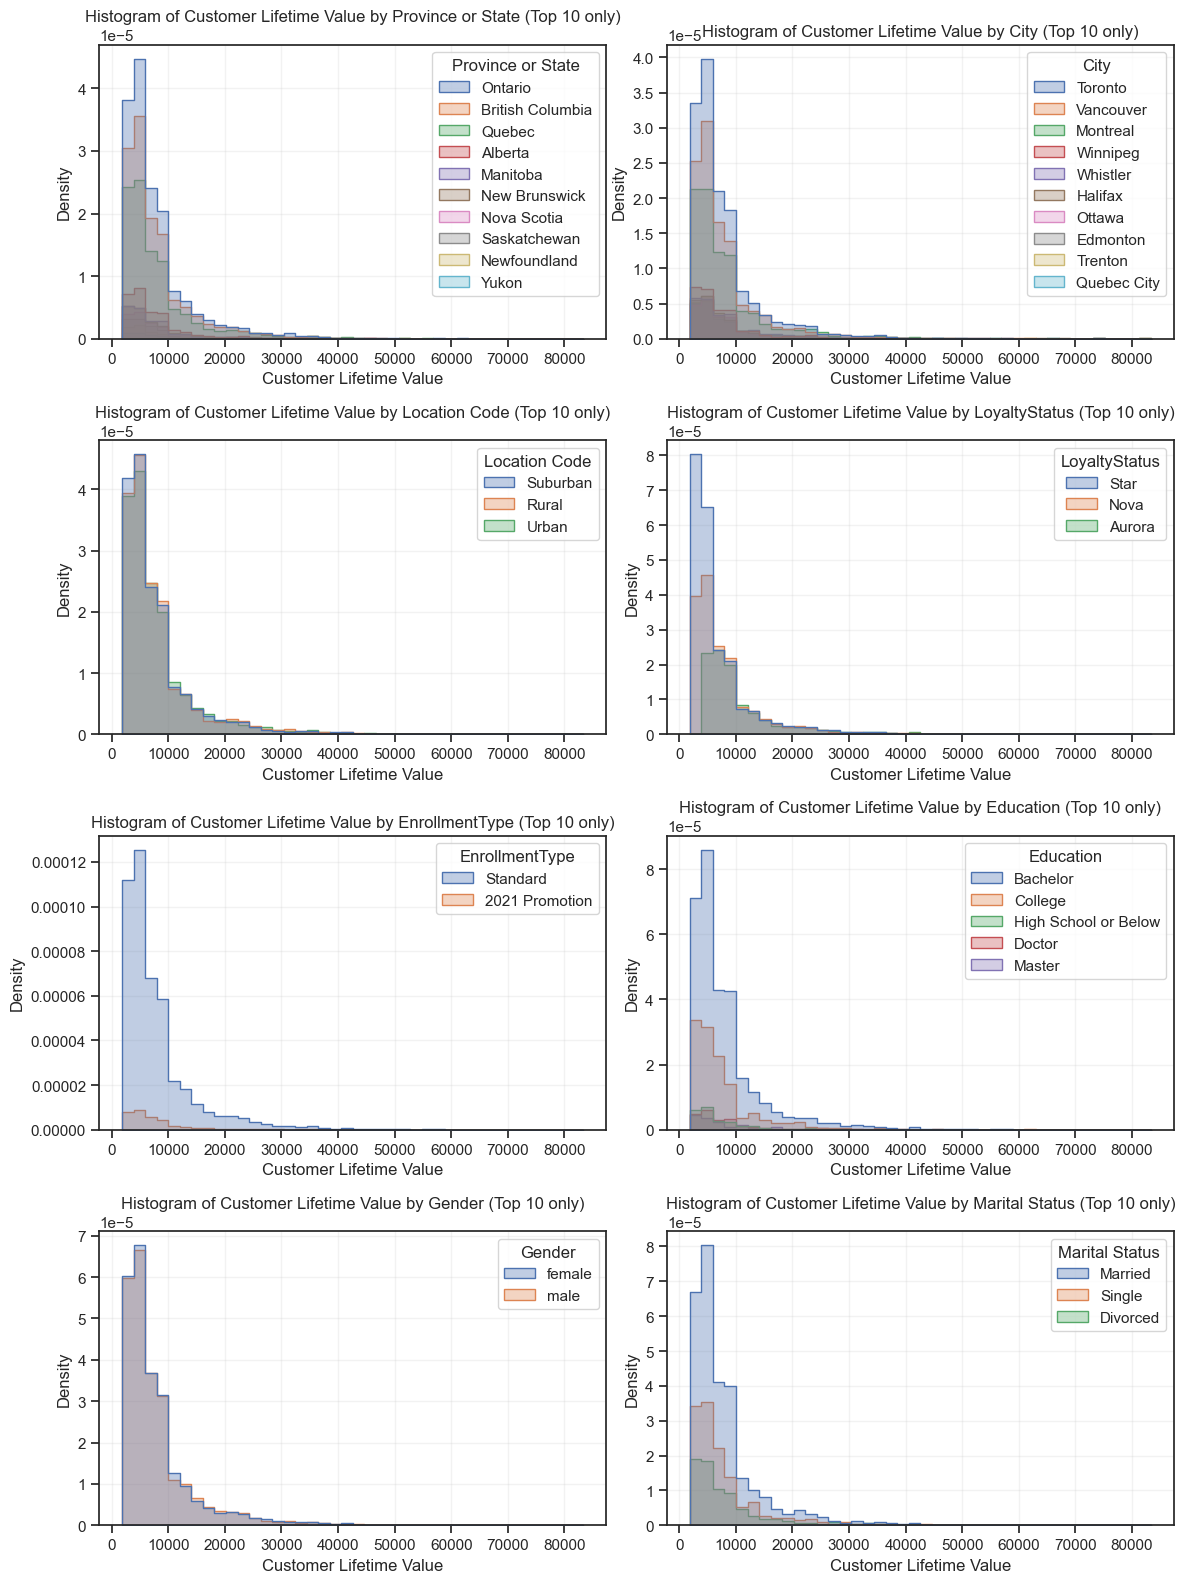

In [542]:
plot_hist_by_categories(
    df=customers_db,
    numeric_col="Customer Lifetime Value",
    cat_cols=["Province or State", "City", "Location Code", "LoyaltyStatus", "EnrollmentType", "Education", "Gender", "Marital Status"]
)

**- Across every category, CLV is heavily right-skewed with a long high-value tail; category curves mostly overlap, indicating weak marginal differences. The geography signals are faint when considered in isolation; any meaningful divergence in CLV is likely conditional on confounders such as income and tenure rather than being driven directly by region, city, or location type.**

**- The only consistent deviation is EnrollmentType, where the 2021 promo looks slightly lower, but that is likely confounded by tenure.**

#### Tenure by category:

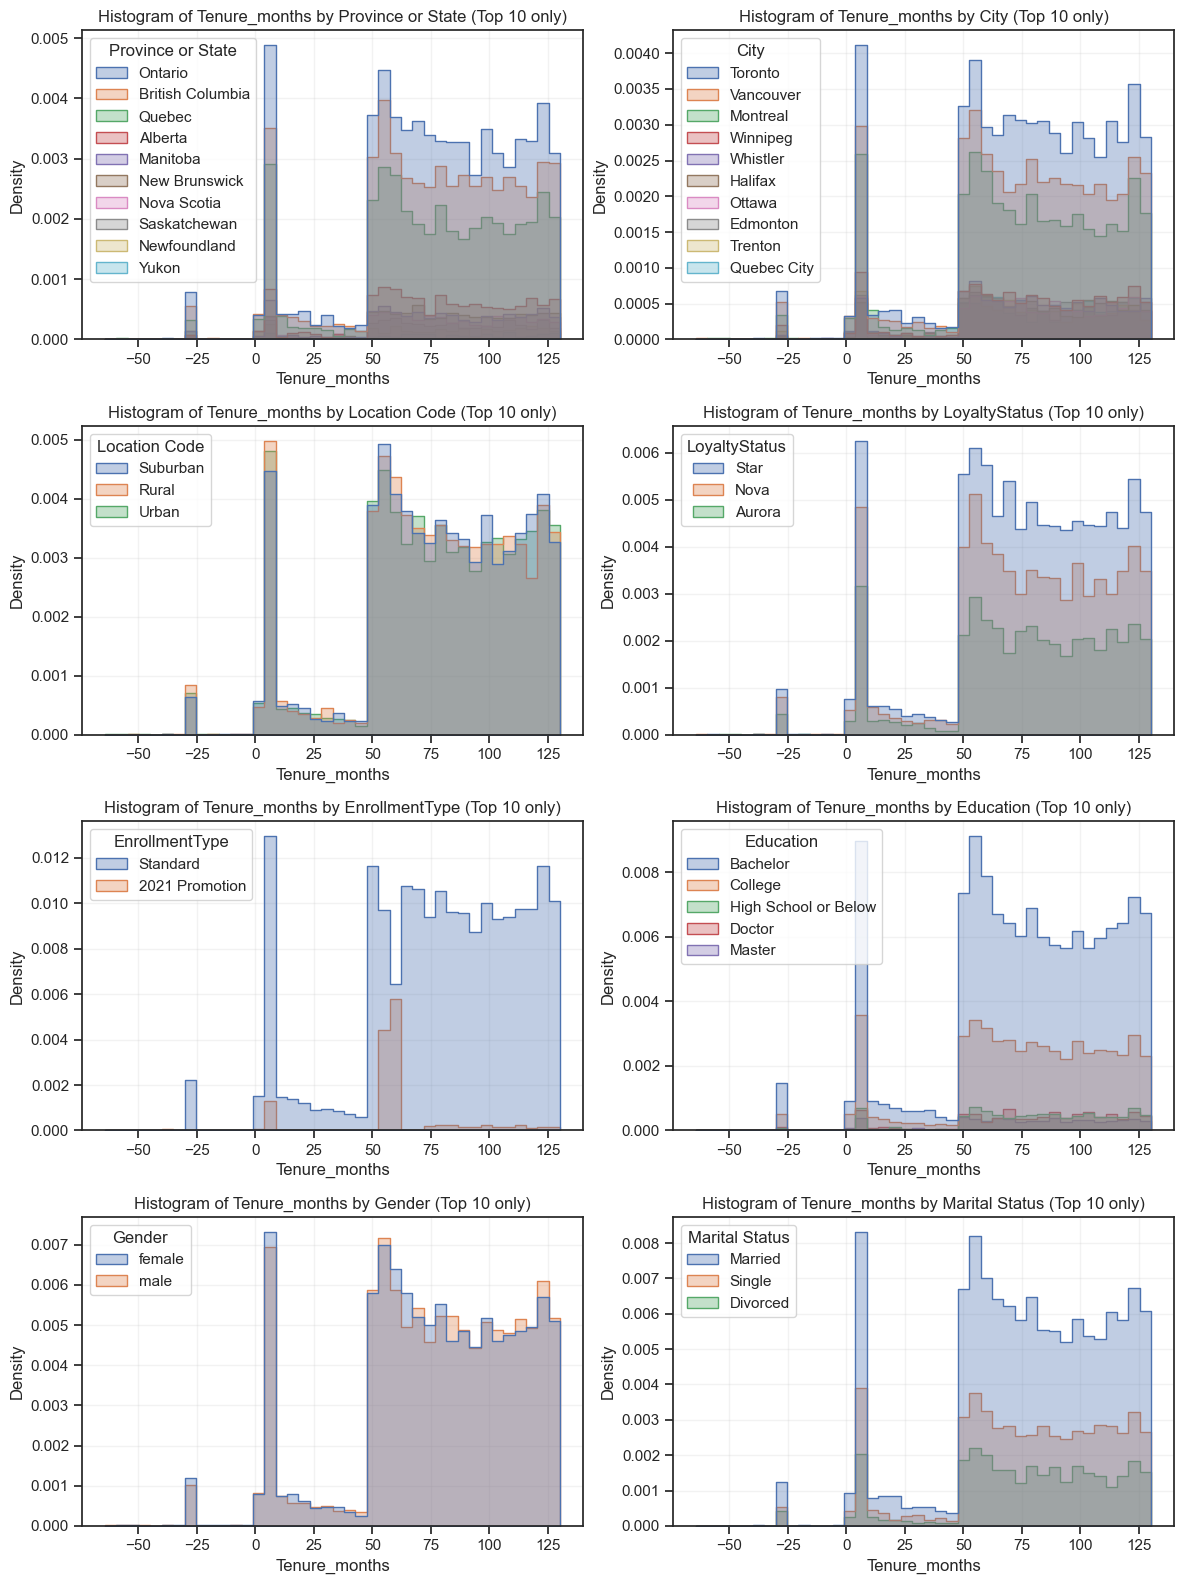

In [543]:
plot_hist_by_categories(
    df=customers_db,
    numeric_col="Tenure_months",
    cat_cols=["Province or State", "City", "Location Code", "LoyaltyStatus", "EnrollmentType", "Education", "Gender", "Marital Status"]
)

- **The program is mature: most customers have 4–10+ years of tenure (~50–125 months).**
- **Across every category, tenure_months distribution is very similar; category curves mostly overlap, indicating weak marginal differences. The only consistent deviation is EnrollmentType, where the Standard cohort spans broadly ~50–125m and the 2021 Promotion line is a thin ridge concentrated near the ~55–70m band and much smaller everywhere else, which is consistent with a recent, small cohort.**
- **Provincial curves stack almost perfectly, city curves differ mainly by sample size rather than position, and Urban/Suburban/Rural show only very slight, unstable variations across the distribution. Taken together, the geography signal for tenure is weak: the program appears to have rolled out uniformly across regions, with observed tenure patterns driven far more by cohort timing than by where customers live.**

#### Income by category:

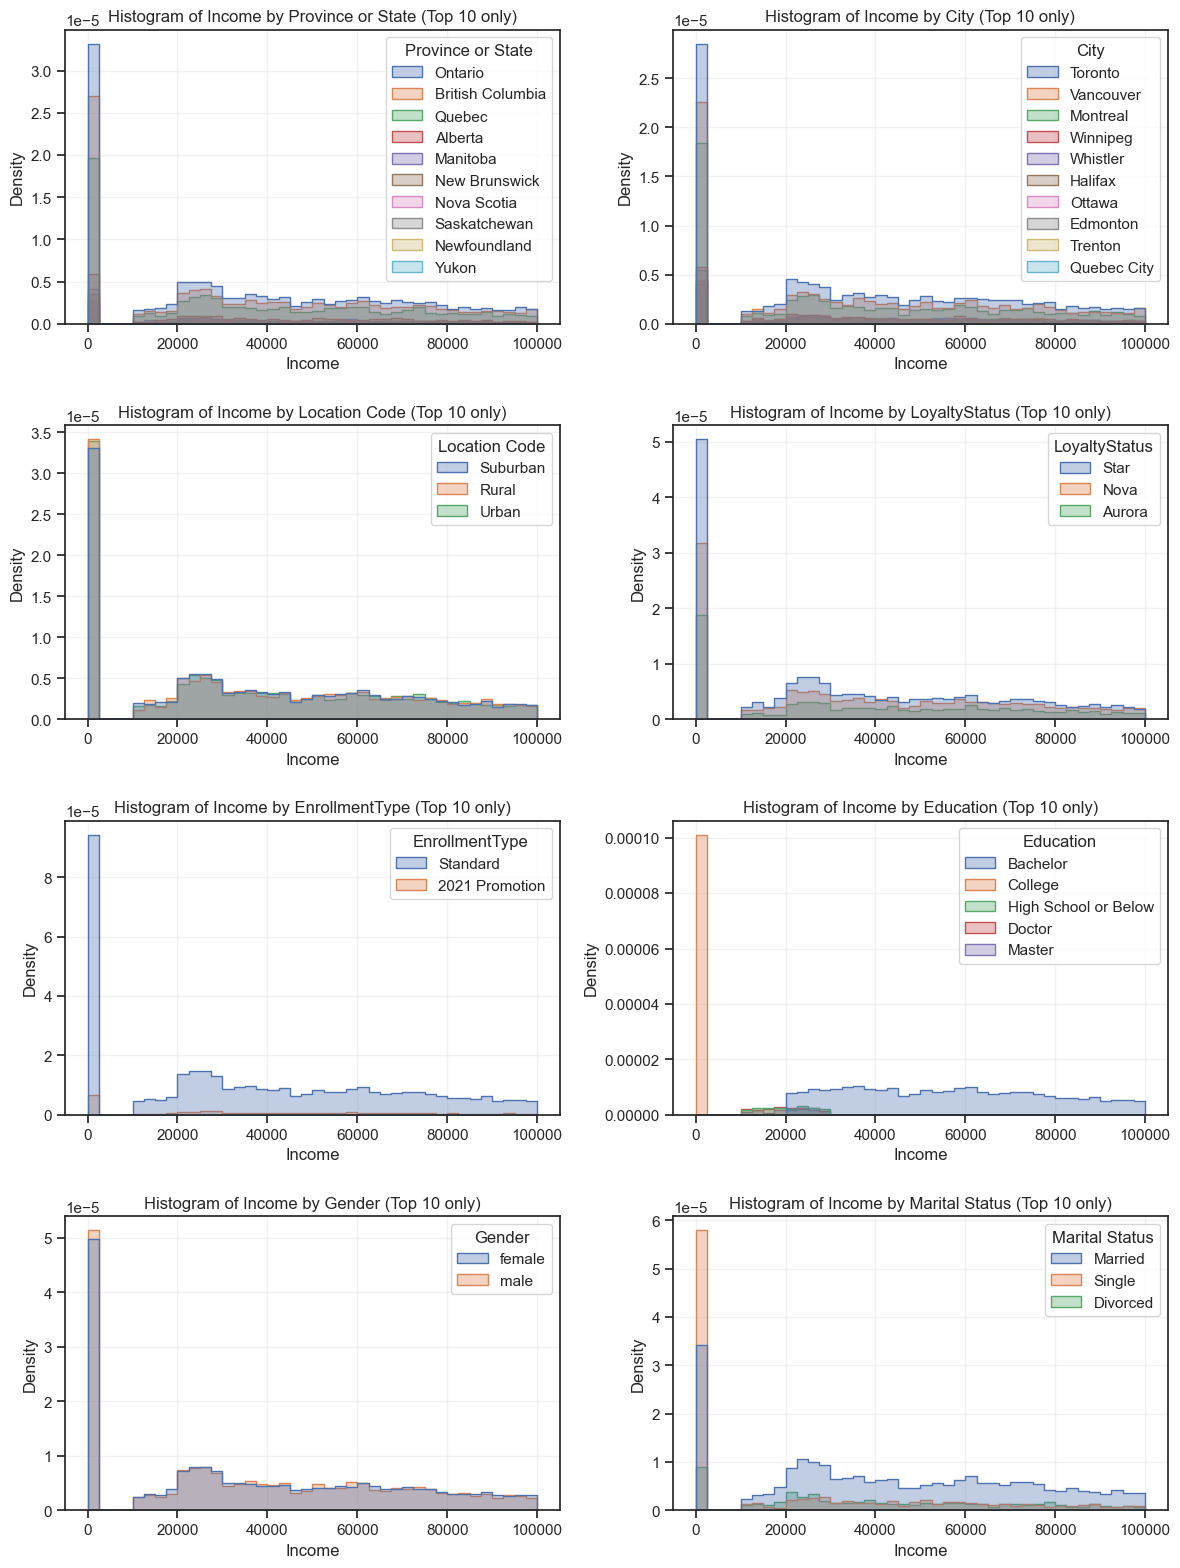

In [544]:
plot_hist_by_categories(
    df=customers_db,
    numeric_col="Income",
    cat_cols=["Province or State", "City", "Location Code", "LoyaltyStatus", "EnrollmentType", "Education", "Gender", "Marital Status"]
)

- **Income has a bimodal distribution with a very large spike at 0, plus a broad right-skewed positive distribution up to ~100k.**

- **Income is not segmented by LoyaltyStatus, geographical region (Province or State, City, Location Code), EnrollmentType, or Gender since across these categories, income distribution is very similar and category curves mostly overlap.**

- **The income spike at 0 is dominated by College students, consistent with students reporting no income. Among positive incomes,there is heavy overlap: Bachelor has the broadest mass across 25k–80k; High-School or Below concentrates lower (≈15k–40k).**

- **There are modest differences by Education and by Marital Status, but the overlap is substantial so the effect size is likely small to moderate.**

### Geographical analysis:

In [545]:
def normalize_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .map(lambda t: "".join(
             c for c in unicodedata.normalize("NFKD", t) if not unicodedata.combining(c)
         ))
         .str.strip()
         .str.lower()
    )

gdf = gpd.read_file(f"zip+https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_CAN_shp.zip!gadm41_CAN_1.shp")

def choropleth_canada_gadm_fast(
    metric: str = "count",               
    value: str | None = None,            
    condition: pd.Series | None = None,  
    customers_key: str = "Province or State",
    admin1_dir: str = "gadm41_CAN_shp",  
    cmap: str = "OrRd",
    title: str | None = None,
    figsize: tuple = (10, 7),
):

    name_col = "NAME_1" if "NAME_1" in gdf.columns else next(c for c in gdf.columns if "NAME" in c.upper())


    ALIASES = {
        "newfoundland": "newfoundland and labrador"
    }


    key_left  = normalize_series(customers_db[customers_key]).replace(ALIASES)
    key_right = normalize_series(gdf[name_col])


    if metric == "count":
        agg = key_left.to_frame("k").groupby("k").size().rename("metric").reset_index()
    elif metric in {"median", "mean", "p95"}:
        if value is None: raise ValueError("`value` é obrigatório para median/mean/p95.")
        vals = pd.to_numeric(customers_db[value], errors="coerce")
        tmp = pd.DataFrame({"k": key_left, "v": vals})
        if metric == "median":
            agg = tmp.groupby("k")["v"].median().rename("metric").reset_index()
        elif metric == "mean":
            agg = tmp.groupby("k")["v"].mean().rename("metric").reset_index()
        else:
            agg = tmp.groupby("k")["v"].quantile(0.95).rename("metric").reset_index()
    elif metric == "share":
        if condition is None: raise ValueError("`condition` booleana é obrigatória para share.")
        tmp = pd.DataFrame({"k": key_left, "f": condition.astype(float)})
        agg = tmp.groupby("k")["f"].mean().rename("metric").reset_index()
    else:
        raise ValueError("metric deve ser 'count','median','mean','p95' ou 'share'.")

    gdf_merged = gdf.merge(agg, how="left", left_on=key_right, right_on="k")

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    gdf_merged.plot(
        column="metric", cmap=cmap, linewidth=0.6, edgecolor="white",
        legend=True, ax=ax,
        missing_kwds={"color": "#eeeeee", "hatch": "///", "label": "No data"}
    )
    ax.set_axis_off()
    if title is None:
        title = ("Customers by province/territory" if metric=="count"
                 else "Share by province/territory" if metric=="share"
                 else f"{metric.capitalize()} of {value} by province/territory")
    ax.set_title(f"{title} (Canada, GADM L1)", fontsize=12)
    plt.tight_layout()
    plt.show()

    unmatched = sorted(set(agg["k"]) - set(key_right.unique()))
    if unmatched:
        print("Unmatched (post-normalization) province names from customers_db:", unmatched)


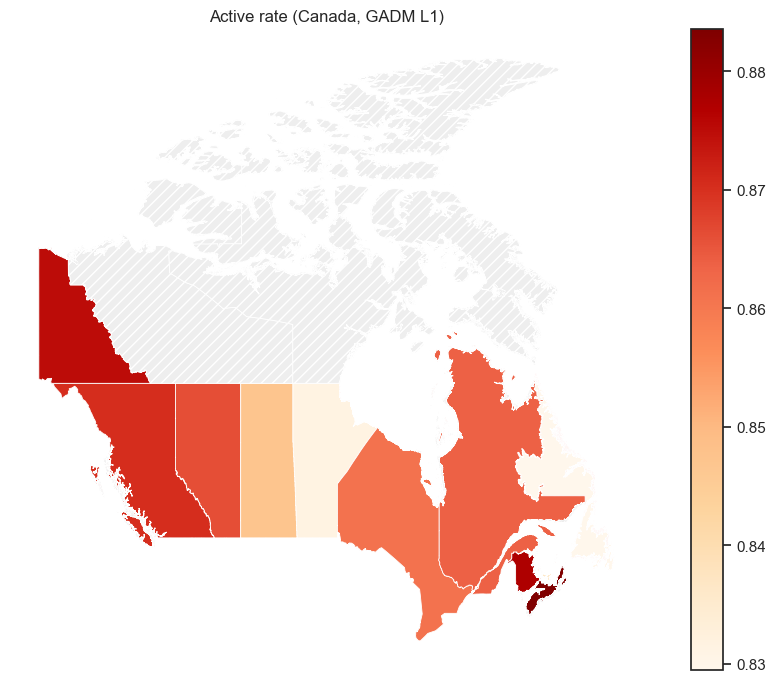

In [546]:
choropleth_canada_gadm_fast(metric="share", condition=customers_db["CancellationDate"].isna(), title="Active rate")

**Active rates are uniformly high across Canada (≈0.83–0.89), but a ~6 point gap remains. A clear regional pattern emerges: the far West (Yukon/British Columbia) and Atlantic (Prince Edward Island/Nova Scotia) lead while the Prairies lag (especially Manitoba then Saskatchewan). Ontario and Quebec sit stably in the middle.**

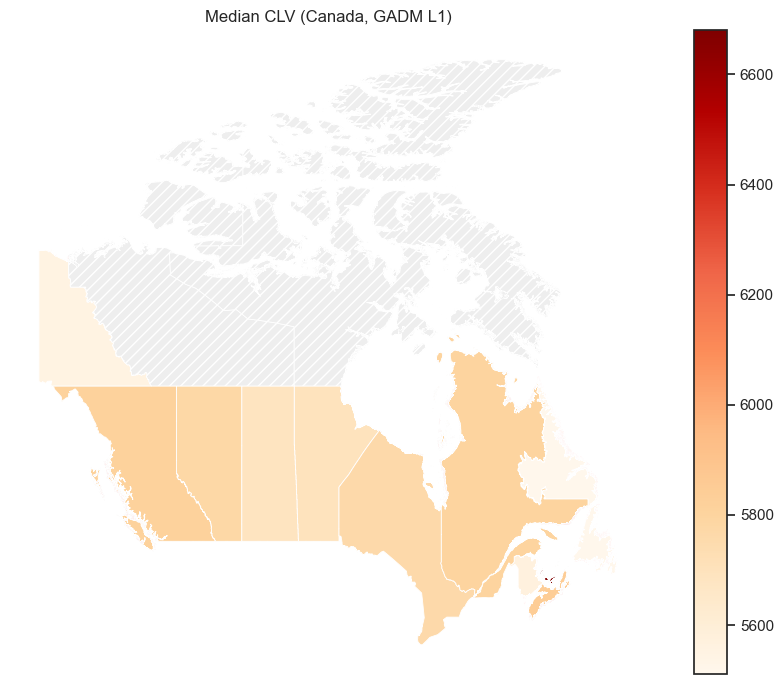

In [547]:
choropleth_canada_gadm_fast(metric="median", value="Customer Lifetime Value", title="Median CLV")

**- From the map, all province sit at almost at the same pale panel. So, geographical difference is not substancial.**

**- Median CLV is fairly uniform across Canada (≈$5.6k–$6.7k), with a modest ~$1.1k spread. A mild regional pattern appears: Quebec and New Brunswick sit slightly above the national median; Ontario and Nova Scotia are near the middle; the Prairies—especially Manitoba (lowest) and then Saskatchewan—trail, with Alberta and British Columbia only slightly higher. Newfoundland & Labrador is lower-middle, and Yukon does not show a clear premium.**

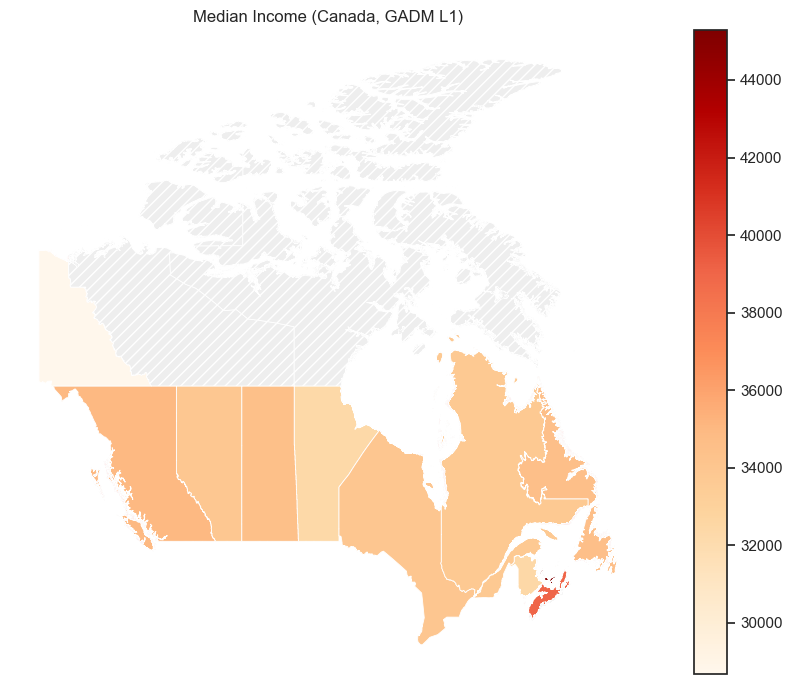

In [548]:
choropleth_canada_gadm_fast(metric="median", value="Income", title="Median Income")

**Median income varies moderately across Canada (≈$29k–$45k), with a clear peak in Prince Edward Island (highest) and Nova Scotia also elevated. A broad middle band - Ontario, Quebec, Alberta, British Columbia, and New Brunswick - clusters near the national median. The lower end appears in Manitoba, Saskatchewan, and Newfoundland & Labrador, while Yukon shows no obvious premium (Northwest Territories/Nunavut not in scope).**

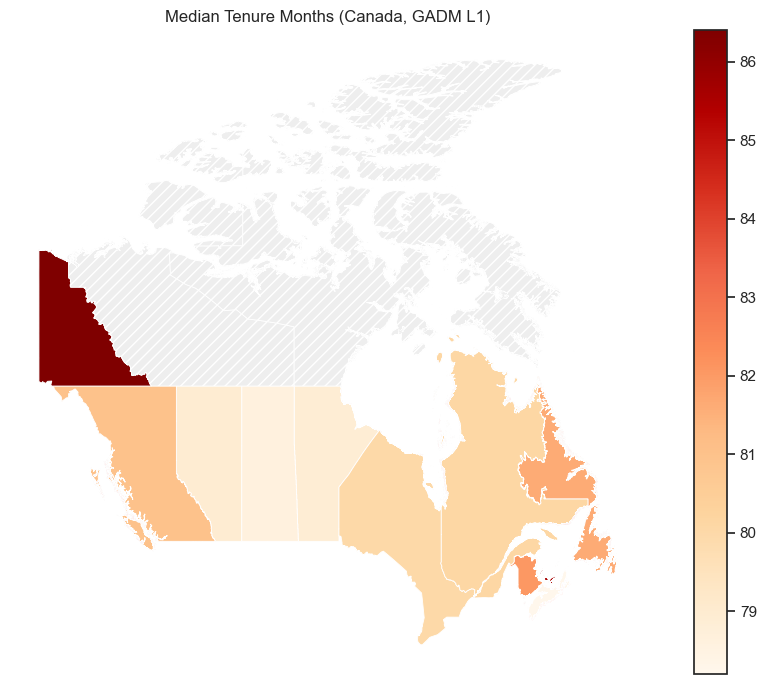

In [549]:
choropleth_canada_gadm_fast(metric="median", value="Tenure_months", title="Median Tenure Months")

**- Median tenure varies modestly across Canada (≈77–85 months), with a clear peak in Yukon. Quebec and New Brunswick are above the national middle, while Nova Scotia and Newfoundland sit around the mid-band and Prince Edward Island is mid-lower. The lowest tenure appears in the Prairies (Manitoba and Saskatchewan) with Alberta and British Columbia just above them but still on the lower side. Ontario is lower-middle.**

**- Overall, geography explains limited tenure variation aside from the Yukon outlier.**

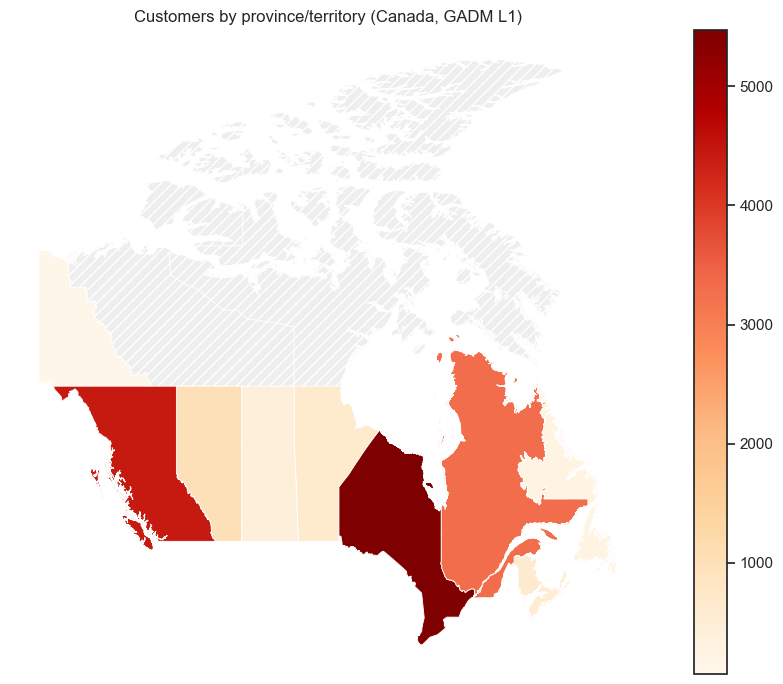

In [550]:
choropleth_canada_gadm_fast(metric="count")

**- Customer counts are highly concentrated in a few provinces, with a clear peak in Ontario (largest base), followed by British Columbia and Alberta. Quebec holds a sizable but smaller base than Ontario. The Prairies (Manitoba and Saskatchewan) are low, and the Atlantic provinces (Nova Scotia, New Brunswick, Newfoundland, Prince Edward Island) are smallest. Yukon is minimal.**

**- This uneven footprint means provincial KPIs (active rate, CLV, income) might be biased by customer counts, and results for small provinces (PEI, Yukon) will be volatil.**

# DATA PREPROCESSING:

### 1.1.4. Data inconsistencies:

#### Different customers with same loyalty#:

- **Records with the duplicate Loyalty# belong to different customers.** 
- **1 loyalty number is assigned to more than one customer.**

**These records are inconsistent records, that might disrupt relationships between customers.db and flights.db.**

In [551]:
duplicated_loyalty_rows = customers_db.duplicated(subset=["Loyalty#"], keep=False)

num_rows_dup = duplicated_loyalty_rows.sum()

pct_rows_dup = num_rows_dup / len(customers_db) * 100

print(f"Total rows with duplicated Loyalty#: {num_rows_dup}")
print(f"% of rows with duplicated Loyalty#: {pct_rows_dup:.2f}%")

Total rows with duplicated Loyalty#: 327
% of rows with duplicated Loyalty#: 1.93%


**The total percentage of records with duplicated loyalty# is 1.93%, which is <5%, so we'll remove these records.**

In [552]:
customers_db = customers_db[~duplicated_loyalty_rows].copy()

customers_db.reset_index(drop=True, inplace=True)


In [553]:
duplicated_loyalty_rows = customers_db.duplicated(subset=["Loyalty#"], keep=False)

num_rows_dup = duplicated_loyalty_rows.sum()

pct_rows_dup = num_rows_dup / len(customers_db) * 100

print(f"Total rows with duplicated Loyalty#: {num_rows_dup}")
print(f"% of rows with duplicated Loyalty#: {pct_rows_dup:.2f}%")

Total rows with duplicated Loyalty#: 0
% of rows with duplicated Loyalty#: 0.00%


### Postal Code - structure:

Canada Postal Code Rules:
- Letter Digit Letter [space] Digit Letter Digit,

Allowed letters:
- 1st: A B C E G H J K L M N P R S T V X Y
- 3rd/5th: any of the above plus W Z (i.e., exclude D F I O Q U)

In [554]:
# 1) Normalization helper
def normalize_postal(s: pd.Series) -> pd.Series:
    out = s.astype("string").str.upper().str.strip()
    out = out.str.replace(r"\s+", " ", regex=True)
    out = out.str.replace(r"^([A-Z]\d[A-Z])\s?(\d[A-Z]\d)$", r"\1 \2", regex=True)
    return out

# 2) Validation helpers
FIRST_OK = set(list("ABCEGHJKLMNPRSTVXY"))      # allowed 1st letter
LETTER_OK = set(list("ABCEGHJKLMNPRSTVWXYZ"))   # allowed letters at 3rd/5th

def postal_reason(pc: str) -> str:
    if pc is None or pd.isna(pc):
        return "missing"

    pc = str(pc).strip().upper().replace("  ", " ")
    pc_no_space = pc.replace(" ", "")
    if len(pc_no_space) != 6:
        return "wrong length"

    a1, n2, a3, n4, a5, n6 = pc_no_space

    if a1 not in FIRST_OK:
        return "invalid first letter"
    if not n2.isdigit():
        return "pos2 must be digit"
    if a3 not in LETTER_OK:
        return "invalid 3rd letter"
    if not n4.isdigit():
        return "pos4 must be digit"
    if a5 not in LETTER_OK:
        return "invalid 5th letter"
    if not n6.isdigit():
        return "pos6 must be digit"

    if " " in pc and not re.fullmatch(r"[A-Z]\d[A-Z] \d[A-Z]\d", pc):
        return "spacing format"
    return ""

# 3) Apply normalization + validation
pc_raw  = customers_db["Postal code"]
pc_norm = normalize_postal(pc_raw)

reasons = pc_norm.map(postal_reason)

valid_mask   = reasons.eq("")
missing_mask = reasons.eq("missing")
invalid_mask = ~(valid_mask | missing_mask)

# 4) Summary
total       = len(customers_db)
num_valid   = valid_mask.sum()
num_missing = missing_mask.sum()
num_invalid = invalid_mask.sum()

print(f"Valid postal codes:    {num_valid:,} ({num_valid/total*100:.2f}%)")
print(f"Missing postal codes:  {num_missing:,} ({num_missing/total*100:.2f}%)")
print(f"Invalid postal codes:  {num_invalid:,} ({num_invalid/total*100:.2f}%)")

# 5) Breakdown of invalid reasons (exclude 'missing')
reason_counts_invalid = reasons[invalid_mask].value_counts().sort_values(ascending=False)
print("\nInvalid reasons (top):")
print(reason_counts_invalid)

# 6) Inspect invalid rows (only truly invalid, not missing)
invalid_rows = (
    customers_db.loc[invalid_mask, ["Loyalty#","Customer Name","Province or State","City","Postal code"]]
    .assign(PostalCode_Normalized=pc_norm[invalid_mask], Reason=reasons[invalid_mask])
)

# optional: rows with missing postal code
missing_rows = customers_db.loc[missing_mask, ["Loyalty#","Customer Name","Province or State","City","Postal code"]]


Valid postal codes:    13,966 (84.16%)
Missing postal codes:  0 (0.00%)
Invalid postal codes:  2,628 (15.84%)

Invalid reasons (top):
Postal code
invalid 5th letter      1228
invalid 3rd letter       964
invalid first letter     436
Name: count, dtype: int64


**There are 15.79% of invalid postal codes (Postal codes that do not respect the Canadian Rules). This is a significant percentage records, indicating that this features might not be a good representation of customer location.**

**Since the percentage of records with invalid postal codes is 15.82% which is a high percentage to drop, we decided to replace those invalid values by NaN.**

In [555]:
pc_raw = customers_db["Postal code"]
pc_norm = normalize_postal(pc_raw)

reasons = pc_norm.map(postal_reason)
valid_mask = reasons.eq("")

# write normalized values back
customers_db["Postal code"] = pc_norm

# mark truly invalid (not valid, not missing)
invalid_mask = reasons.ne("") & reasons.ne("missing")

# replace invalid postal codes with NaN
customers_db.loc[invalid_mask, "Postal code"] = np.nan

### Date inconsistencies:

In [557]:
# Cancellation before enrollment:
bad_order_strict = customers_db["CancellationDate"].notna() & (
    customers_db["CancellationDate"] < customers_db["EnrollmentDateOpening"]
)
bad_order_count = bad_order_strict.sum()
bad_order_pct_all = bad_order_strict.mean() * 100  

print(f"Cancellation before enrollment: {bad_order_count} rows "
      f"({bad_order_pct_all:.3f}%)")

# Enrollment or cancellation in the future:
today = pd.Timestamp.today().normalize()
future_enroll = customers_db["EnrollmentDateOpening"] > today
future_cancel = customers_db["CancellationDate"] > today

future_enroll_count = future_enroll.sum()
future_cancel_count = future_cancel.sum()

print(f"Enrollment in the future: {future_enroll_count} rows "
      f"({future_enroll.mean() * 100:.3f}%)")
print(f"Cancellation in the future: {future_cancel_count} rows "
      f"({future_cancel.mean() * 100:.3f}%)")

Cancellation before enrollment: 199 rows (1.199%)
Enrollment in the future: 0 rows (0.000%)
Cancellation in the future: 0 rows (0.000%)


- **There are 202 (1.194% <5%) of records in which cancellation date occurs before enrollment date. These records are invalid, so we will exclude them.**

In [558]:
# rows where cancellation happens before enrollment
mask_bad = customers_db["CancellationDate"] < customers_db["EnrollmentDateOpening"]

customers_db = customers_db[~mask_bad].copy()
customers_db.reset_index(drop=True, inplace=True)

In [559]:
bad_order_strict = customers_db["CancellationDate"].notna() & (
    customers_db["CancellationDate"] < customers_db["EnrollmentDateOpening"]
)
bad_order_count = bad_order_strict.sum()
bad_order_pct_all = bad_order_strict.mean() * 100  

print(f"Cancellation before enrollment: {bad_order_count} rows "
      f"({bad_order_pct_all:.3f}%)")

print(f"Enrollment in the future: {future_enroll_count} rows "
      f"({future_enroll.mean() * 100:.3f}%)")

Cancellation before enrollment: 0 rows (0.000%)
Enrollment in the future: 0 rows (0.000%)


### 1.1.3. Missing Values:

In [560]:
total_missing = customers_db.isna().sum().sum()
total_missing_pct = (total_missing / flights_db.size) * 100  

print(f"Total missing values: {total_missing:,} ({total_missing_pct:.2f}%) ")

missing_by_col = (
    customers_db.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: d["missing_count"] / len(customers_db) * 100)
    .sort_values("missing_pct", ascending=False)
)

print("\nMissing values by column (count and % of rows):")
print(missing_by_col)

Total missing values: 21,132 (0.35%) 

Missing values by column (count and % of rows):
                         missing_count  missing_pct
CancellationDate                 14329    87.398597
CLV_per_income                    4169    25.428484
Postal code                       2594    15.821897
Income                              20     0.121988
Customer Lifetime Value             20     0.121988
Province or State                    0     0.000000
Customer Name                        0     0.000000
Loyalty#                             0     0.000000
City                                 0     0.000000
Gender                               0     0.000000
Longitude                            0     0.000000
Latitude                             0     0.000000
Marital Status                       0     0.000000
Location Code                        0     0.000000
Education                            0     0.000000
EnrollmentDateOpening                0     0.000000
LoyaltyStatus                

**In EDA we concluded that missing values for CLV and Income are common to the same customers.**

- **Missing values in CancelationDate represent active customers (customers who did not cancel). Since most values are NaN, we decided to drop this feature and replace it with a newly created feature **IsCancelled** representing whether the customer left the program or not**

In [561]:
customers_db = customers_db.drop(columns=["CancellationDate"])

**For income and CLV we decided to remove these rows since missing values percentage together ~0.24%, which is neglegible.**

In [562]:
# rows where BOTH Income and CLV are missing
mask_both_missing = (
    customers_db["Income"].isna() &
    customers_db["Customer Lifetime Value"].isna()
)

print("Rows to drop:", mask_both_missing.sum()/ len(customers_db) * 100)

# keep only rows where at least one of them is present
customers_db = customers_db[~mask_both_missing].copy()
customers_db.reset_index(drop=True, inplace=True)


Rows to drop: 0.12198841110094541


**For Postal Code, we decided to impute missing values with mode:**

In [563]:
postal_mode = customers_db["Postal code"].mode(dropna=True).iloc[0]
print("Postal code mode:", postal_mode)

customers_db["Postal code"] = customers_db["Postal code"].fillna(postal_mode)

Postal code mode: V5R 1W3


**The ratio CLV_per_income is undefined for customers with zero income (≈25%), so we discarded this engineered variable and used Income and CLV separately**

In [564]:
customers_db = customers_db.drop(columns=["CLV_per_income"])


In [565]:
total_missing = customers_db.isna().sum().sum()
total_missing_pct = (total_missing / flights_db.size) * 100  

print(f"Total missing values: {total_missing:,} ({total_missing_pct:.2f}%) ")

missing_by_col = (
    customers_db.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: d["missing_count"] / len(customers_db) * 100)
    .sort_values("missing_pct", ascending=False)
)

print("\nMissing values by column (count and % of rows):")
print(missing_by_col)

Total missing values: 0 (0.00%) 

Missing values by column (count and % of rows):
                         missing_count  missing_pct
Loyalty#                             0          0.0
Customer Name                        0          0.0
Province or State                    0          0.0
City                                 0          0.0
Latitude                             0          0.0
Longitude                            0          0.0
Postal code                          0          0.0
Gender                               0          0.0
Education                            0          0.0
Location Code                        0          0.0
Income                               0          0.0
Marital Status                       0          0.0
LoyaltyStatus                        0          0.0
EnrollmentDateOpening                0          0.0
Customer Lifetime Value              0          0.0
EnrollmentType                       0          0.0
IsCancelled                       

## Outliers:

In [567]:
metric_features.remove("CLV_per_income")

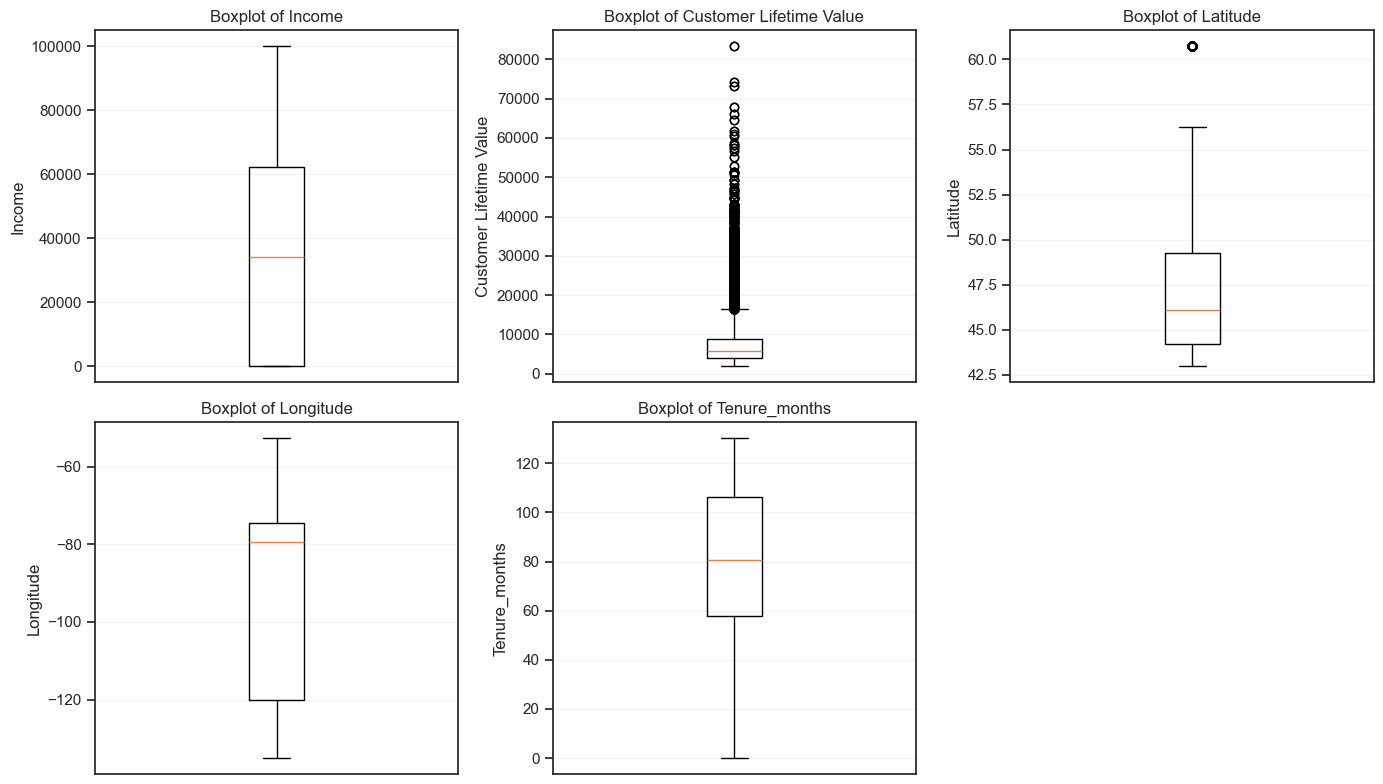

In [568]:
boxplot_grid(customers_db, metric_features, ncols=3, figsize=(14, 8), showfliers=True)

In [569]:
def iqr_outlier_summary(df: pd.DataFrame, cols, k: float = 1.5):

    rows = []
    masks = {}

    n = len(df)

    for col in cols:
        s = df[col].dropna()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        mask = (df[col] < lower) | (df[col] > upper)
        n_out = mask.sum()
        pct_out = n_out / n * 100

        masks[col] = mask

        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": n_out,
            "pct_outliers": pct_out
        })

    summary_df = pd.DataFrame(rows)

    print("-" * 70)
    print("IQR outlier summary")
    print("-" * 70)
    for _, r in summary_df.iterrows():
        print(f"Feature        : {r['feature']}")
        print(f"  Q1           : {r['Q1']:.3f}")
        print(f"  Q3           : {r['Q3']:.3f}")
        print(f"  IQR          : {r['IQR']:.3f}")
        print(f"  Lower bound  : {r['lower_bound']:.3f}")
        print(f"  Upper bound  : {r['upper_bound']:.3f}")
        print(f"  Outliers     : {int(r['n_outliers'])} "
              f"({r['pct_outliers']:.2f}% of rows)")
        print("-" * 70)

    return summary_df, masks


In [570]:
iqr_summary, iqr_masks = iqr_outlier_summary(customers_db, metric_features)

----------------------------------------------------------------------
IQR outlier summary
----------------------------------------------------------------------
Feature        : Income
  Q1           : 0.000
  Q3           : 62375.000
  IQR          : 62375.000
  Lower bound  : -93562.500
  Upper bound  : 155937.500
  Outliers     : 0 (0.00% of rows)
----------------------------------------------------------------------
Feature        : Customer Lifetime Value
  Q1           : 3979.390
  Q3           : 8936.970
  IQR          : 4957.580
  Lower bound  : -3456.980
  Upper bound  : 16373.340
  Outliers     : 1447 (8.84% of rows)
----------------------------------------------------------------------
Feature        : Latitude
  Q1           : 44.231
  Q3           : 49.283
  IQR          : 5.052
  Lower bound  : 36.654
  Upper bound  : 56.860
  Outliers     : 106 (0.65% of rows)
----------------------------------------------------------------------
Feature        : Longitude
  Q1         

In [577]:
# Outlier IQR method:
out_iqr = iqr_masks["Latitude"] | iqr_masks["Customer Lifetime Value"]

filters_man = (
    (customers_db['Customer Lifetime Value']> 64500)
    |
    (customers_db['Latitude']> 60)
)

# Both methods combined
out_combined = out_iqr & filters_man

keep_mask = ~out_combined

customers_no_outliers = customers_db[keep_mask].copy()

pct_kept = 100 * customers_no_outliers.shape[0] / customers_db.shape[0]
print(f"Percentage of data kept after removing combined outliers: {pct_kept:.2f}%")


Percentage of data kept after removing combined outliers: 99.28%


Outliers in both Latitude and CLV are plausible values and not a consequence of data errors. However, for modeling testing reasons, we decided to create two datasets: 
- One removing extreme values in both these variables (using a combination of IQR and threshold methods to be more conservative)
- One without outlier removal 

By removing outliers, the total percentage removed from the entire datasets is less than 1%.

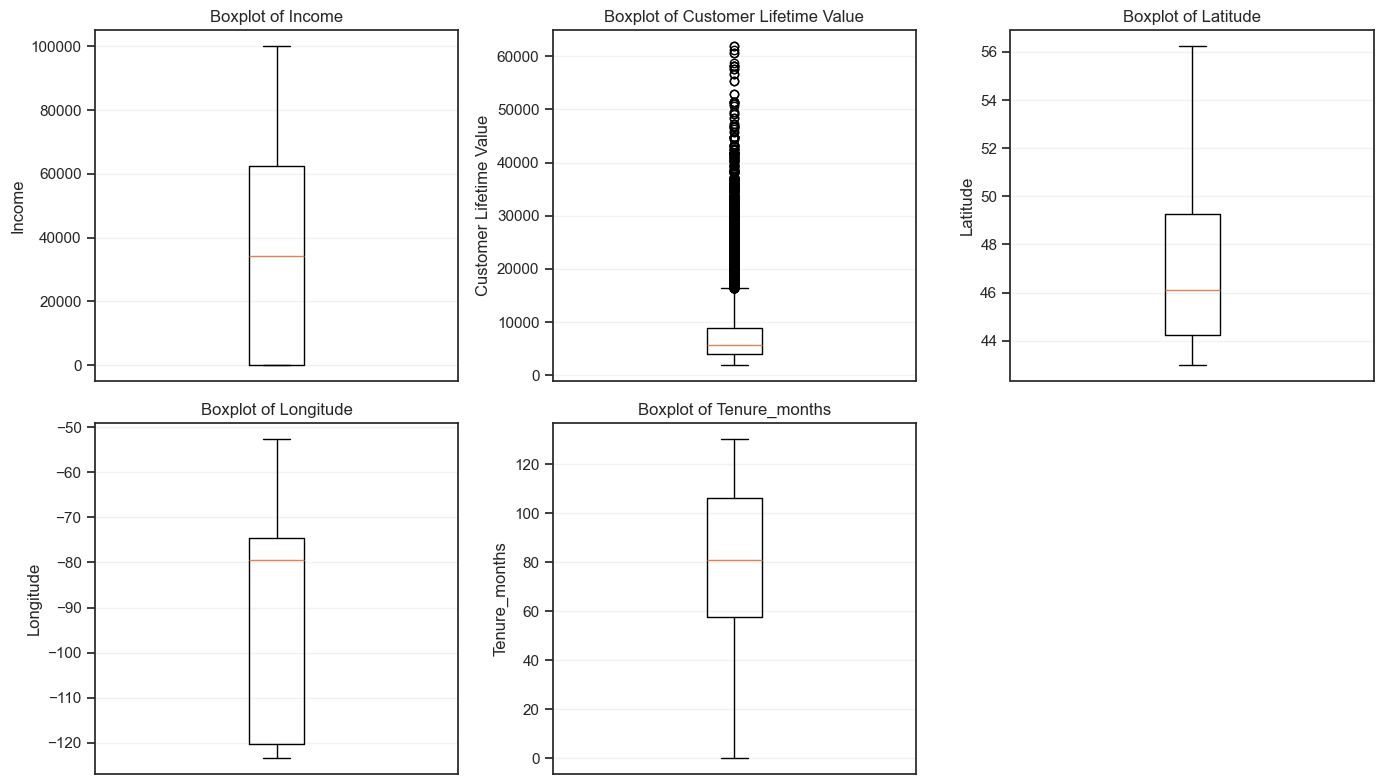

In [578]:
boxplot_grid(customers_no_outliers, metric_features, ncols=3, figsize=(14, 8), showfliers=True)